# Análisis y visualización de señales EEG - BITalino (10 registros)

El objetivo es convertir las señales crudas (ADC) medidas con el BITalino a su unidad física (EEG en µV) y visualizarlas, separando las condiciones del experimento, cada una registrada en 2 sujetos (Emma y Vivi):

1. **Lectura basal**
2. **Apertura y cierre de ojos**
3. **Susurro de preguntas**
4. **Música tranquila**
5. **Música hardcore**

Librería usada para leer y convertir las señales: [`opensignalsreader`](https://github.com/PGomes92/opensignalsreader).

**Importante sobre los archivos `.txt`:** este notebook asume que tus 10 archivos `.txt` de OpenSignals están guardados en Google Drive, dentro de la carpeta compartida (recuerda haber agregado el acceso directo a tu "Mi unidad" si la carpeta pertenece a otra persona).

In [ ]:
# Instalar dependencias (solo la primera vez que corras el notebook)
!pip install -q opensignalsreader matplotlib numpy scipy

## 1. Montar Google Drive y ubicar la carpeta de datos

En **Google Colab**, ejecuta la siguiente celda: montará tu Drive. Ajusta `CARPETA_DATOS` con la ruta real (respetando espacios, tildes, mayúsculas y paréntesis tal como aparecen en Drive).

In [ ]:
import os

# Carpeta de datos por defecto: la misma carpeta donde está el notebook
CARPETA_DATOS = "."

try:
    from google.colab import drive
    drive.mount('/content/drive')

    # --------------------------------------------------------------
    # EDITA esta línea con la ruta real dentro de tu Drive
    # --------------------------------------------------------------
    CARPETA_DATOS = "/content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG"

    print(f"Google Drive montado. Carpeta de datos configurada en: {CARPETA_DATOS}")

except ImportError:
    print("No se detectó Google Colab. Se usará la carpeta local del notebook (.)")

print("Contenido de la carpeta de datos:")
if os.path.isdir(CARPETA_DATOS):
    print(os.listdir(CARPETA_DATOS))
else:
    print(f"  [!] La carpeta '{CARPETA_DATOS}' todavía no existe o la ruta es incorrecta.")

Mounted at /content/drive
Google Drive montado. Carpeta de datos configurada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG
Contenido de la carpeta de datos:
['basal_emma.txt', 'basal_emma.h5', 'abre_cierra_emma.txt', 'abre_cierra_emma.h5', 'preguntas_emma.txt', 'preguntas_emma.h5', 'musica_tranquila_emma.txt', 'musica_tranquila_emma.h5', 'musica_hard_emma.txt', 'musica_hard_emma.h5', 'basal_vivi.txt', 'basal_vivi.h5', 'abre_cierra_vivi.txt', 'abre_cierra_vivi.h5', 'preguntas_vivi.txt', 'preguntas_vivi.h5', 'musica_tranquila_vivi.txt', 'musica_tranquila_vivi.h5', 'musica_hard_vivi.txt', 'musica_hard_vivi.h5', 'figuras_Emma_Vivi', 'figuras_bitalino', 'Copia_de_analisis_bitalino_ECG(1).ipynb', 'analisis_bitalino_EEG1.ipynb']


## 2. Configuración: 5 condiciones x 2 sujetos (Emma, Vivi)

Cada condición fue registrada en ambas compañeras, por lo que cada grupo es un diccionario que asocia cada sujeto con su archivo correspondiente (mismo patrón usado en el notebook de ECG, reemplazando "derivación" por "sujeto").

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from opensignalsreader import OpenSignalsReader
from scipy.signal import butter, filtfilt, iirnotch

%matplotlib inline

ARCHIVOS = {
    "Lectura basal": {
        "Emma": "basal_emma.txt",
        "Vivi": "basal_vivi.txt",
    },
    "Apertura y cierre de ojos": {
        "Emma": "abre_cierra_emma.txt",
        "Vivi": "abre_cierra_vivi.txt",
    },
    "Susurro de preguntas": {
        "Emma": "preguntas_emma.txt",
        "Vivi": "preguntas_vivi.txt",
    },
    "Música tranquila": {
        "Emma": "musica_tranquila_emma.txt",
        "Vivi": "musica_tranquila_vivi.txt",
    },
    "Música hardcore": {
        "Emma": "musica_hard_emma.txt",
        "Vivi": "musica_hard_vivi.txt",
    },
}

# Único sensor usado en las mediciones: EEG
CANAL = "EEG"
UNIDAD = "µV"

# Carpeta donde se guardarán las figuras generadas
CARPETA_SALIDA = os.path.join(CARPETA_DATOS, "figuras_bitalino")

# Colores y orden de capas (zorder) por condición, para futuras comparaciones
COLORES = {
    "Lectura basal": "tab:green",
    "Apertura y cierre de ojos": "tab:blue",
    "Susurro de preguntas": "tab:orange",
    "Música tranquila": "tab:purple",
    "Música hardcore": "tab:red",
}

### Nota: parche para un bug conocido de `opensignalsreader`

La librería `opensignalsreader` (v0.2.2) tiene un **bug** en su función interna `_check_ranges`, usada para avisar cuando una señal convertida se sale del rango físico esperado del sensor (para EEG: ±41.24 µV). El mensaje de advertencia está mal armado internamente y, en vez de solo mostrar un *warning*, hace que el programa se detenga con un `TypeError: must be real number, not str`.

Esto ocurre típicamente si el valor mínimo o máximo de tu señal EEG supera ese rango (común en EEG por artefactos de parpadeo, movimiento o mal contacto del electrodo). La celda siguiente reemplaza esa función rota por una versión corregida, para que el aviso se muestre correctamente como una advertencia y el notebook no se detenga.

In [ ]:
import opensignalsreader.transfer_functions.bit as bit_tf
import warnings

def _check_ranges_corregido(signal, sensor):
    """
    Versión corregida de _check_ranges() de opensignalsreader.
    La original tiene un bug al construir el mensaje de advertencia
    (pasa un string donde se espera un número), lo que provoca un
    TypeError en vez de solo mostrar el warning.
    """
    minimo, maximo = bit_tf.ranges[sensor]
    unidad = bit_tf.units[sensor]

    if signal.min() < minimo:
        warnings.warn(
            f"Valor mínimo de la señal {sensor} ({signal.min():.2f}{unidad}) "
            f"está por debajo del rango esperado del sensor ({minimo}{unidad})."
        )
    if signal.max() > maximo:
        warnings.warn(
            f"Valor máximo de la señal {sensor} ({signal.max():.2f}{unidad}) "
            f"está por encima del rango esperado del sensor ({maximo}{unidad})."
        )

# Reemplaza la función rota de la librería por la corregida
bit_tf._check_ranges = _check_ranges_corregido

## 3. Filtros necesarios para una señal EEG

A diferencia del ECG, la señal EEG tiene amplitudes mucho menores (microvoltios) y la información relevante está contenida en bandas de frecuencia muy específicas, por lo que el filtrado es aún más crítico para poder interpretarla:

- **Filtro pasa-altos (~0.5 Hz):** elimina el *drift* de línea base causado por la impedancia de los electrodos y el sudor, sin afectar la actividad cerebral de interés.
- **Filtro pasa-bajos (~45 Hz):** elimina ruido de alta frecuencia y, sobre todo, contaminación por actividad muscular (EMG) del cuero cabelludo/frente, que se superpone fácilmente a la señal EEG si el sujeto tensiona la cara o mueve la mandíbula.
- **Filtro notch (50 o 60 Hz):** elimina la interferencia de la red eléctrica. En Perú corresponde a 60 Hz.
- En conjunto, esto equivale a un **filtro pasa-banda de aproximadamente 0.5-45 Hz** combinado con el notch de línea eléctrica — rango donde se concentran las bandas clínicas relevantes del EEG (delta a gamma baja).

### Bandas de frecuencia del EEG y su relación con las dinámicas del experimento

| Banda | Rango de frecuencia | Estado mental asociado |
|---|---|---|
| **Delta (δ)** | 0.5 - 4 Hz | Sueño profundo, inconsciencia |
| **Theta (θ)** | 4 - 8 Hz | Somnolencia, relajación profunda, meditación |
| **Alfa (α)** | 8 - 13 Hz | Relajación con ojos cerrados, calma mental |
| **Beta (β)** | 13 - 30 Hz | Estado de alerta, concentración, pensamiento activo |
| **Gamma (γ)** | > 30 Hz | Procesamiento cognitivo complejo, alta concentración |

Con base en esto, para tu informe puedes relacionar cada dinámica con la banda que se espera sea predominante:

- **Lectura basal:** actividad **Theta**, por ser un estado de vigilia activa con los ojos abiertos y atención dirigida a la lectura.
- **Apertura y cierre de ojos:** es la condición clásica para evidenciar el **ritmo Alfa**: al cerrar los ojos debería aumentar la amplitud de Alfa (8-13 Hz), especialmente notorio en electrodos occipitales, y disminuir al abrir los ojos nuevamente (bloqueo alfa o *alpha blocking*).
- **Susurro de preguntas:** actividad **Beta**, asociada al procesamiento atencional/cognitivo de escuchar y responder.
- **Música tranquila:** tiende a favorecer un incremento relativo de **Alfa/Theta**, asociado a un estado de relajación.
- **Música hardcore:** tiende a favorecer un incremento relativo de **Beta**, asociado a mayor activación/alerta por el estímulo auditivo intenso.

*(Nota: estas asociaciones son el comportamiento esperado según la literatura; confirmarlas en tus propios datos requeriría un análisis espectral, el cual no se incluye en este notebook).*

## 4. Funciones de carga, filtrado y graficado

In [ ]:
def cargar_senal(ruta_archivo, canal):
    """
    Carga un archivo OpenSignals/BITalino y devuelve:
        t        -> vector de tiempo (s)
        senal    -> señal EEG convertida a µV
        senal_cr -> señal cruda (ADC)
        fs       -> frecuencia de muestreo (Hz)

    Si el archivo aún no existe, devuelve None para no interrumpir el
    resto del notebook mientras vas agregando tus .txt uno por uno.
    """
    if not os.path.isfile(ruta_archivo):
        print(f"  [!] No se encontró el archivo: {ruta_archivo} (aún no agregado)")
        return None

    try:
        acq = OpenSignalsReader(ruta_archivo)
    except TypeError as e:
        print(f"  [!] Error al procesar el archivo {ruta_archivo} (TypeError en inicialización): {e}. Se omite este archivo.")
        return None
    except Exception as e: # Capturar otros errores inesperados durante la inicialización
        print(f"  [!] Error inesperado al inicializar OpenSignalsReader para {ruta_archivo}: {e}. Se omite este archivo.")
        return None

    # --- DEBUGGING LINE ---
    # print(f"  [DEBUG] Atributos disponibles en acq para {ruta_archivo}: {dir(acq)}") # Desactivamos la línea de depuración
    # --- END DEBUGGING LINE ---

    # Obtener la frecuencia de muestreo directamente de acq.sampling_rate
    try:
        fs = acq.sampling_rate
    except AttributeError as e:
        print(f"  [!] No se pudo obtener la frecuencia de muestreo de {ruta_archivo}: {e}. Se omite este archivo.")
        return None

    senal = acq.signal(canal)      # señal convertida a µV
    senal_cr = acq.raw(canal)      # señal cruda (valor ADC)

    t = np.arange(len(senal)) / fs

    return t, senal, senal_cr, fs

In [ ]:
def filtrar_eeg(senal, fs, low=0.8, high=50, notch_freq=60, notch_q=30):
    """
    Filtra una señal EEG:
    - Pasa-banda Butterworth (low-high Hz) para quitar drift de línea base
      y ruido/EMG de alta frecuencia.
    - Notch en notch_freq Hz para quitar interferencia de línea eléctrica.
    """
    nyq = fs / 2

    # Pasa-banda
    b, a = butter(4, [low / nyq, high / nyq], btype="band")
    senal_filtrada = filtfilt(b, a, senal)

    # Notch (línea eléctrica)
    b_notch, a_notch = iirnotch(notch_freq / nyq, notch_q)
    senal_filtrada = filtfilt(b_notch, a_notch, senal_filtrada)

    return senal_filtrada

In [ ]:
def graficar_senal_filtrada(t, senal_original, senal_filtrada, titulo, unidad="µV",
                             carpeta_salida=None, nombre_fig=None):
    """
    Grafica la señal original (de fondo, gris) y la señal filtrada (al frente)
    en una misma figura para comparar el efecto del filtro.
    """
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, senal_original, label="Original", color="gray", alpha=0.5, linewidth=0.7)
    ax.plot(t, senal_filtrada, label="Filtrada", color="tab:blue", linewidth=0.9)
    ax.set_title(titulo)
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel(f"EEG ({unidad})")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()

    if carpeta_salida and nombre_fig:
        os.makedirs(carpeta_salida, exist_ok=True)
        ruta_fig = os.path.join(carpeta_salida, nombre_fig)
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura guardada en: {ruta_fig}")

    return fig

## 5. Ejecutar: graficar los 10 registros (5 condiciones x 2 sujetas)

## 6. Análisis Espectral (Bandas de Frecuencia EEG)

Para cuantificar la actividad en cada banda de frecuencia (delta, theta, alfa, beta, gamma), necesitamos calcular el espectro de potencia de la señal EEG. Esto se hará usando la Transformada Rápida de Fourier (FFT) para obtener la distribución de la energía de la señal en el dominio de la frecuencia.

In [ ]:
from scipy.signal import welch

def calcular_espectro_eeg(senal_filtrada, fs):
    """
    Calcula el espectro de potencia de una señal EEG filtrada y la potencia
    en las bandas de frecuencia clásicas (Delta, Theta, Alfa, Beta, Gamma).
    """
    # Parámetros para Welch's method
    nperseg = int(2 * fs) # Ventana de 2 segundos

    # Calcular la Densidad Espectral de Potencia (PSD) usando el método de Welch
    frecuencias, psd = welch(senal_filtrada, fs, nperseg=nperseg, scaling='density')

    # Definir las bandas de frecuencia del EEG (en Hz)
    bandas_eeg = {
        'Delta': (0.5, 4),
        'Theta': (4, 8),
        'Alfa': (8, 13),
        'Beta': (13, 30),
        'Gamma': (30, 50) # Limitamos a 50 Hz por el filtro pasa-bajos
    }

    potencia_por_banda = {}
    for nombre_banda, (f_min, f_max) in bandas_eeg.items():
        # Encontrar los índices de las frecuencias dentro de la banda
        idx_banda = np.where((frecuencias >= f_min) & (frecuencias <= f_max))[0]
        if len(idx_banda) > 0:
            # Calcular la potencia integrando la PSD en la banda
            potencia = np.trapz(psd[idx_banda], frecuencias[idx_banda])
            potencia_por_banda[nombre_banda] = potencia
        else:
            potencia_por_banda[nombre_banda] = 0.0

    return frecuencias, psd, potencia_por_banda

In [ ]:
def graficar_espectro_eeg(frecuencias, psd, potencia_por_banda, titulo, fs, carpeta_salida=None, nombre_fig=None):
    """
    Grafica el espectro de potencia (PSD) y marca las bandas de frecuencia EEG.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(frecuencias, psd, color='darkblue', linewidth=1.5)

    # Definir las bandas de frecuencia para graficar
    bandas_eeg_plot = {
        'Delta': (0.5, 4, 'red'),
        'Theta': (4, 8, 'orange'),
        'Alfa': (8, 13, 'green'),
        'Beta': (13, 30, 'purple'),
        'Gamma': (30, 50, 'brown')
    }

    for nombre_banda, (f_min, f_max, color) in bandas_eeg_plot.items():
        ax.axvspan(f_min, f_max, color=color, alpha=0.2, label=f'{nombre_banda} ({f_min}-{f_max} Hz)')

    ax.set_title(f'Espectro de Potencia ({titulo})')
    ax.set_xlabel('Frecuencia (Hz)')
    ax.set_ylabel('Densidad Espectral de Potencia (µV^2/Hz)')
    ax.set_xlim(0, min(fs / 2, 60)) # Limitar el eje X a 60 Hz o la frecuencia de Nyquist si es menor
    ax.set_ylim(bottom=0) # Asegurar que el eje Y comience en 0
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()

    if carpeta_salida and nombre_fig:
        os.makedirs(carpeta_salida, exist_ok=True)
        ruta_fig = os.path.join(carpeta_salida, nombre_fig)
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura de espectro guardada en: {ruta_fig}")

    plt.show()
    return fig

/tmp/ipykernel_1441/920855904.py:15: UserWarning: Valor mínimo de la señal EGG (-0.27mV) está por debajo del rango esperado del sensor (-0.27mV).
  warnings.warn(
/tmp/ipykernel_1441/920855904.py:15: UserWarning: Valor mínimo de la señal EEG (-41.25µV) está por debajo del rango esperado del sensor (-41.24µV).
  warnings.warn(


  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_emma_filtrada.png


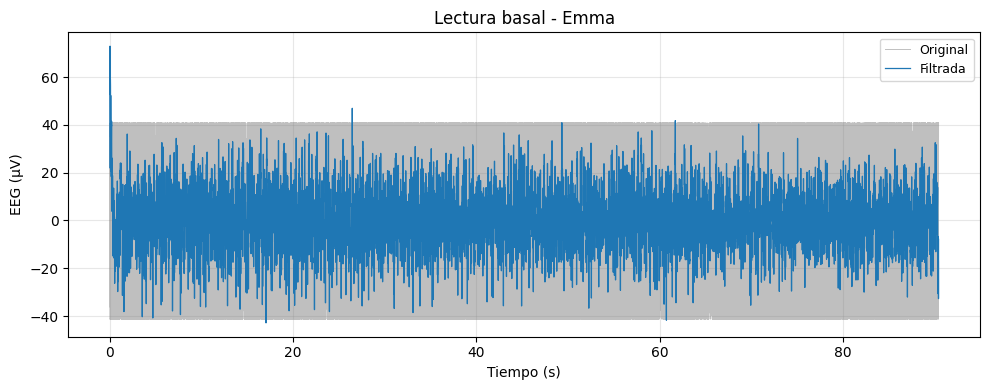

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_vivi_filtrada.png


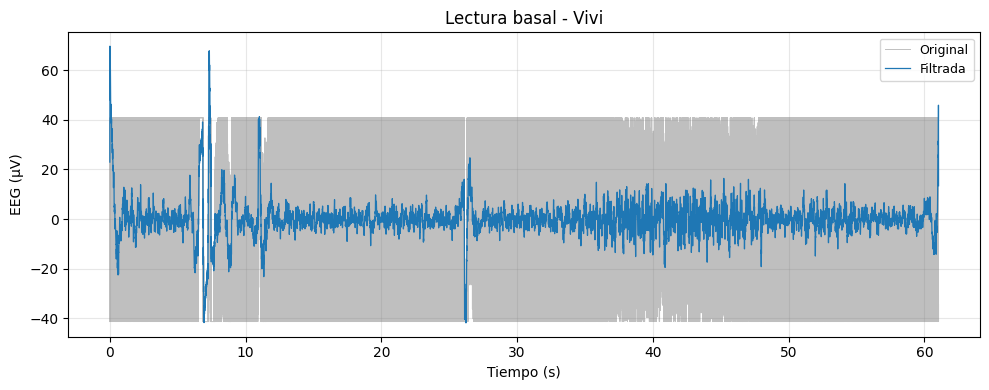

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_emma_filtrada.png


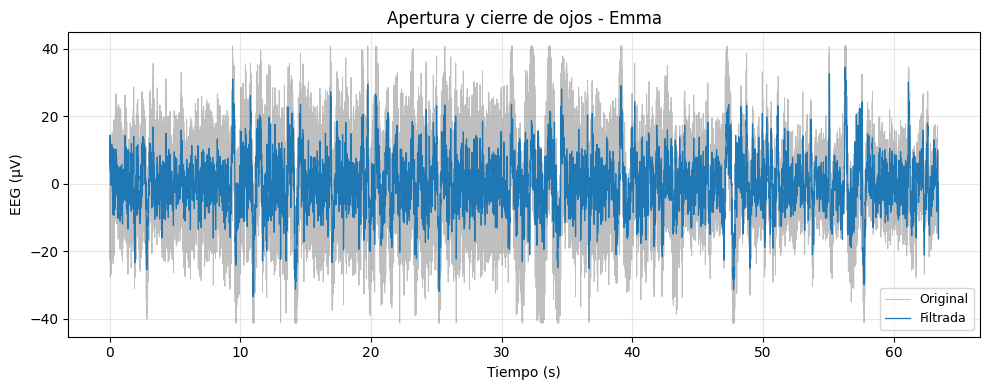

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_vivi_filtrada.png


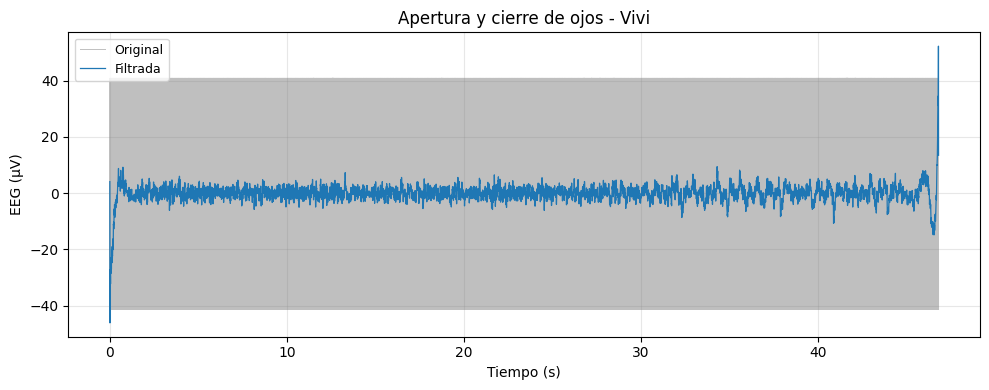

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_emma_filtrada.png


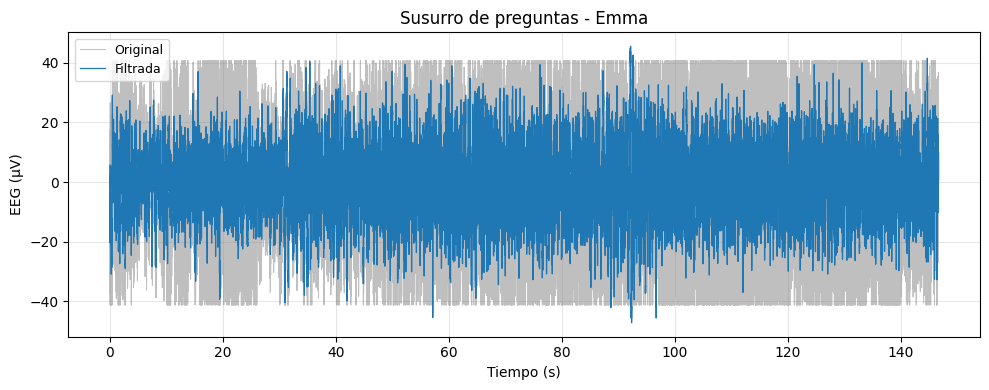

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_vivi_filtrada.png


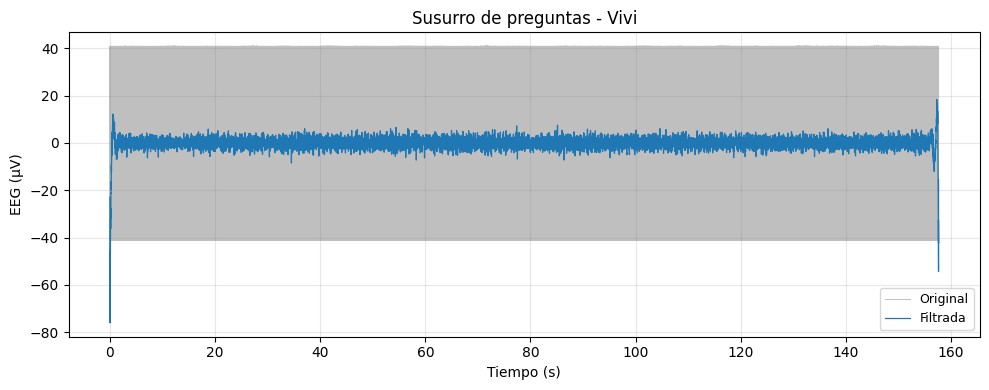

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_emma_filtrada.png


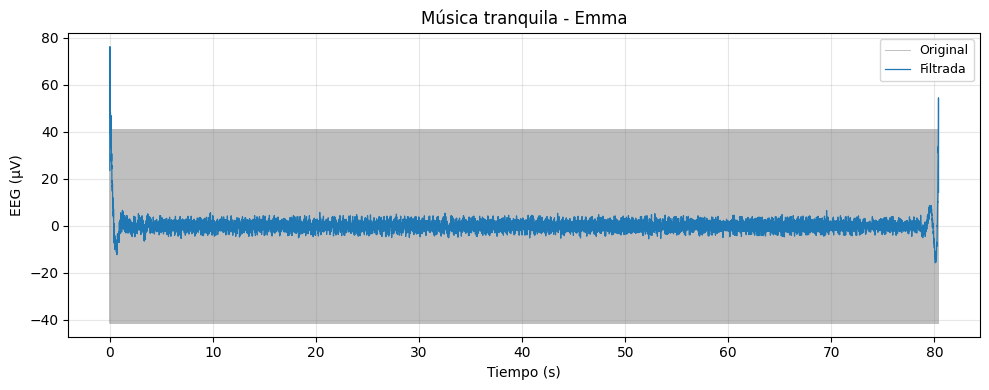

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_vivi_filtrada.png


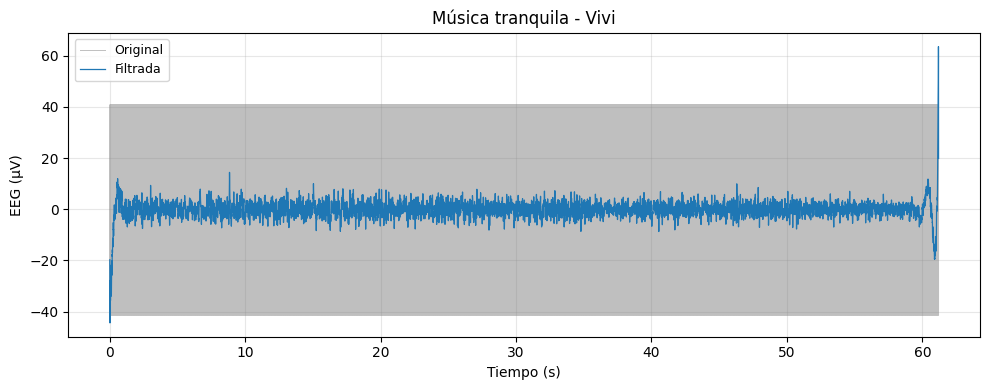

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_emma_filtrada.png


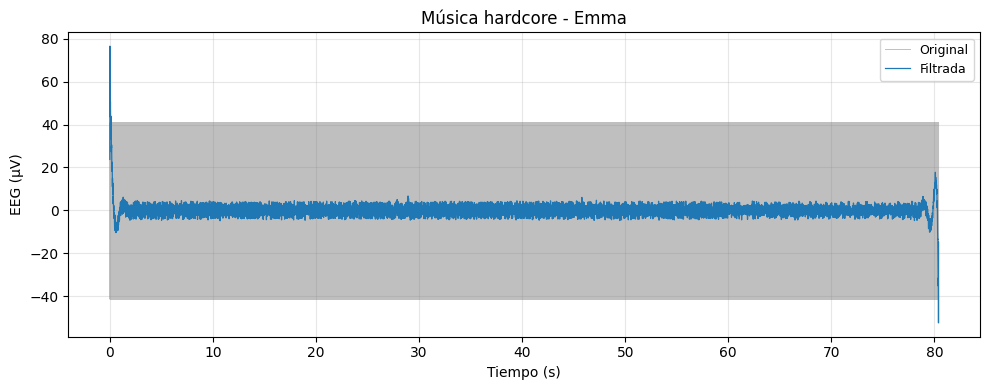

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_vivi_filtrada.png


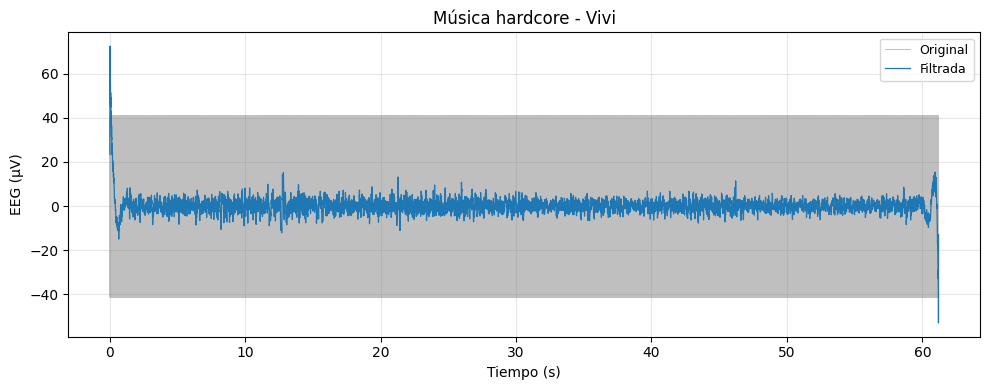

In [ ]:
for nombre_grupo, dict_sujetos in ARCHIVOS.items():
    for sujeto, nombre_archivo in dict_sujetos.items():

        ruta = os.path.join(CARPETA_DATOS, nombre_archivo)
        resultado = cargar_senal(ruta, CANAL)

        if resultado is None:
            continue

        t, senal, senal_cr, fs = resultado
        senal_filtrada = filtrar_eeg(senal, fs)

        titulo = f"{nombre_grupo} - {sujeto}"
        nombre_fig = f"{nombre_grupo}_{sujeto}_filtrada.png".lower().replace(" ", "_")

        graficar_senal_filtrada(t, senal, senal_filtrada, titulo, unidad=UNIDAD,
                                 carpeta_salida=CARPETA_SALIDA, nombre_fig=nombre_fig)
        plt.show()

Ahora que la función `cargar_senal` está modificada para manejar el `TypeError`, el siguiente código debería ejecutar el bucle de graficado, mostrando las figuras para todos los archivos procesados.

/tmp/ipykernel_1441/920855904.py:15: UserWarning: Valor mínimo de la señal EGG (-0.27mV) está por debajo del rango esperado del sensor (-0.27mV).
  warnings.warn(
/tmp/ipykernel_1441/920855904.py:15: UserWarning: Valor mínimo de la señal EEG (-41.25µV) está por debajo del rango esperado del sensor (-41.24µV).
  warnings.warn(


  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_emma_filtrada.png
  -> Banda de frecuencia dominante para Lectura basal - Emma: Beta


/tmp/ipykernel_1441/3637997105.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  potencia = np.trapz(psd[idx_banda], frecuencias[idx_banda])


  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_emma_espectro.png


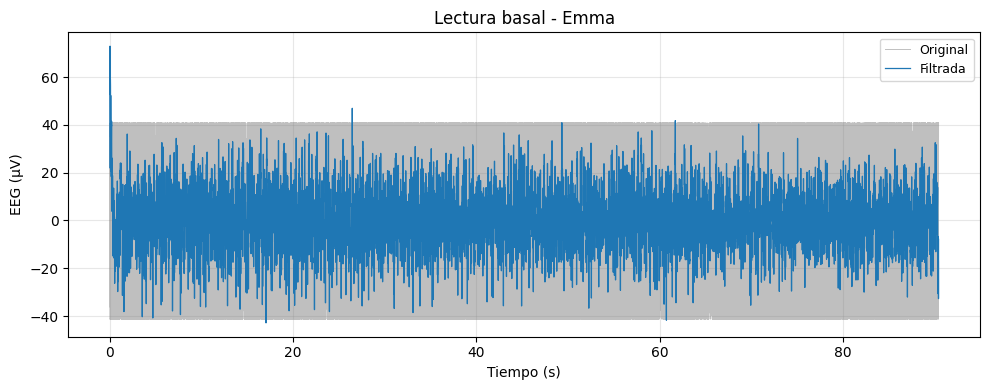

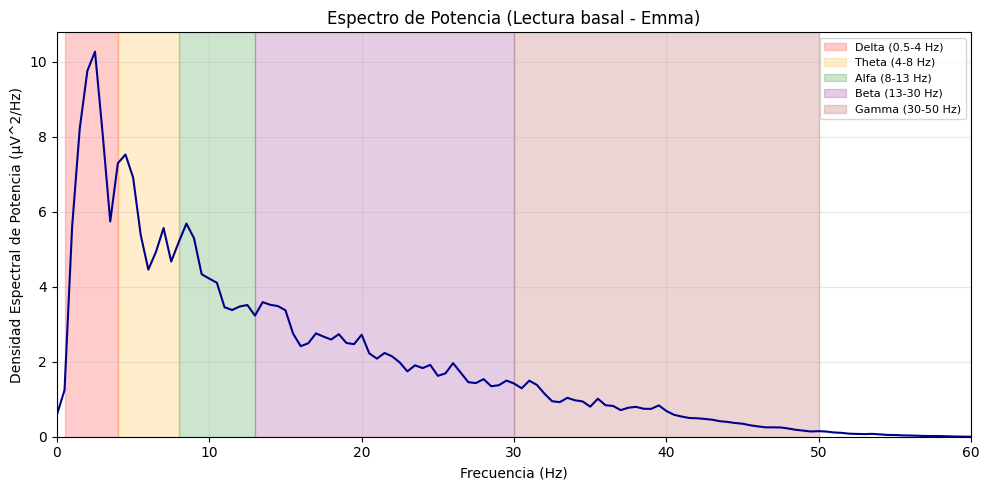

-------------------------------------------------------------------------------------------
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_vivi_filtrada.png
  -> Banda de frecuencia dominante para Lectura basal - Vivi: Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_vivi_espectro.png


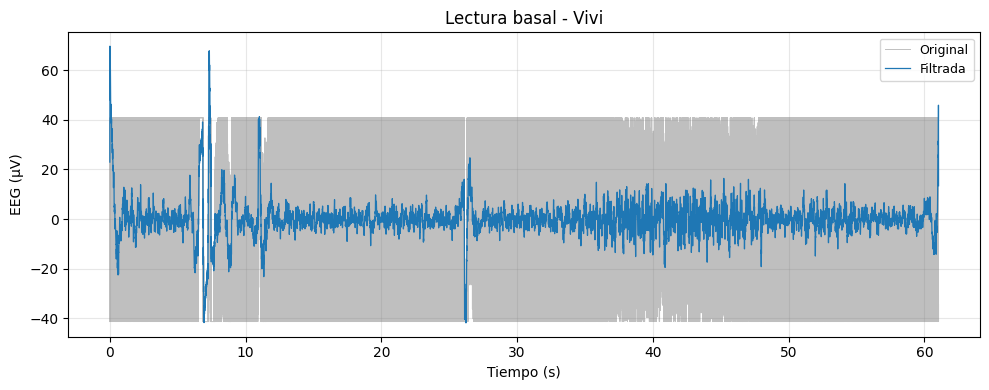

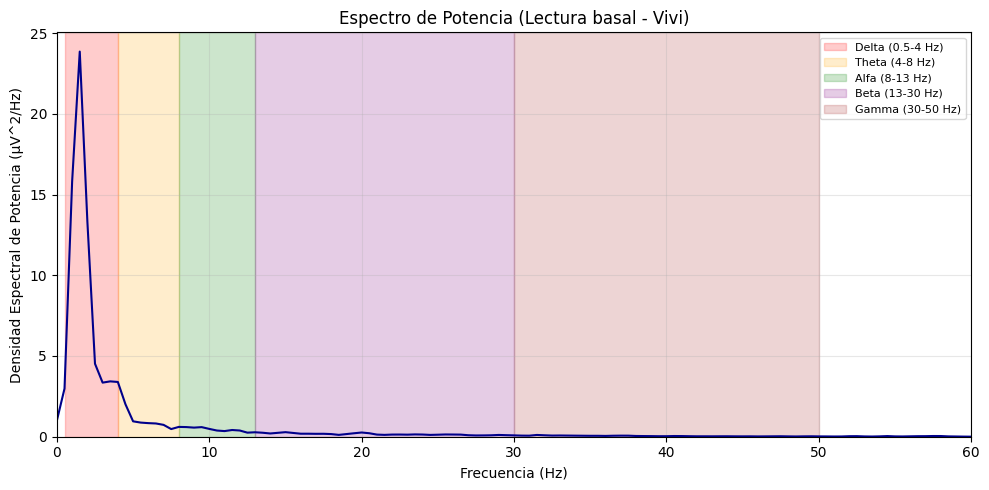

-------------------------------------------------------------------------------------------
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_emma_filtrada.png
  -> Banda de frecuencia dominante para Apertura y cierre de ojos - Emma: Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_emma_espectro.png


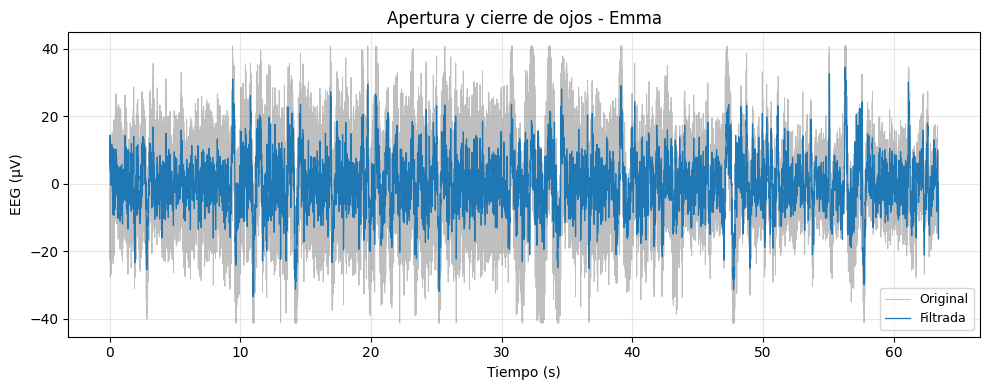

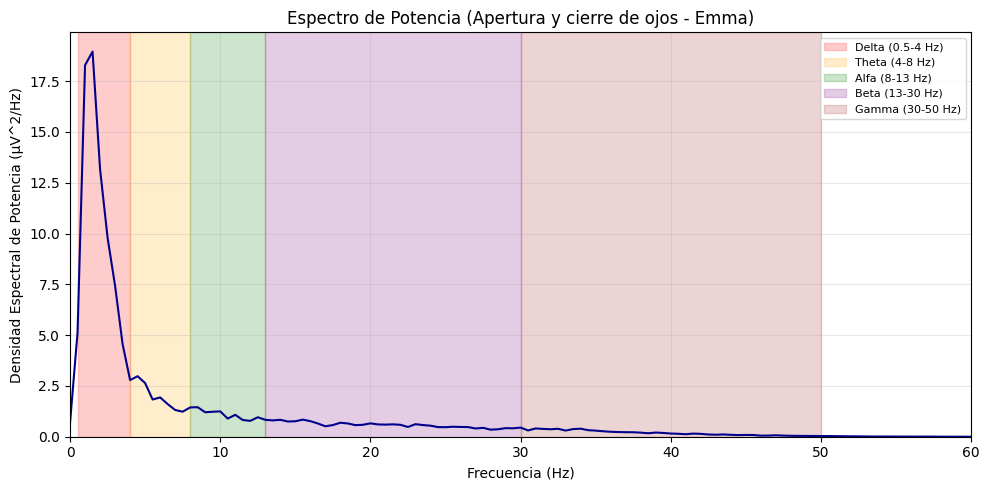

-------------------------------------------------------------------------------------------
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_vivi_filtrada.png
  -> Banda de frecuencia dominante para Apertura y cierre de ojos - Vivi: Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_vivi_espectro.png


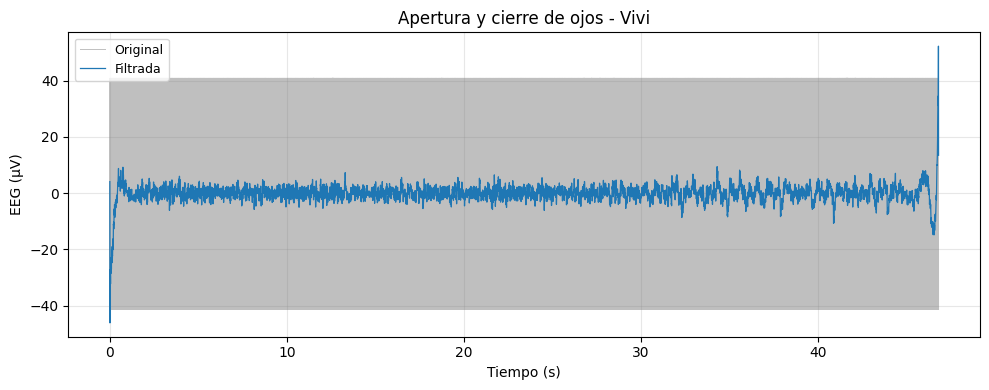

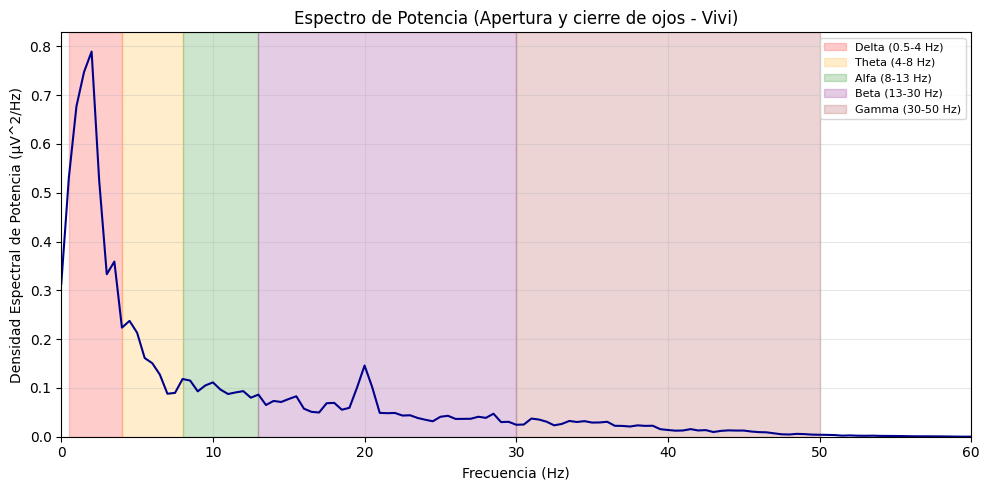

-------------------------------------------------------------------------------------------
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_emma_filtrada.png
  -> Banda de frecuencia dominante para Susurro de preguntas - Emma: Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_emma_espectro.png


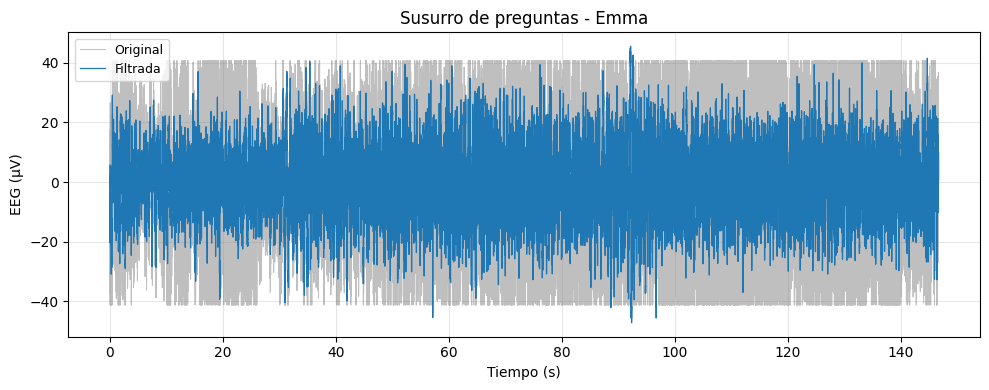

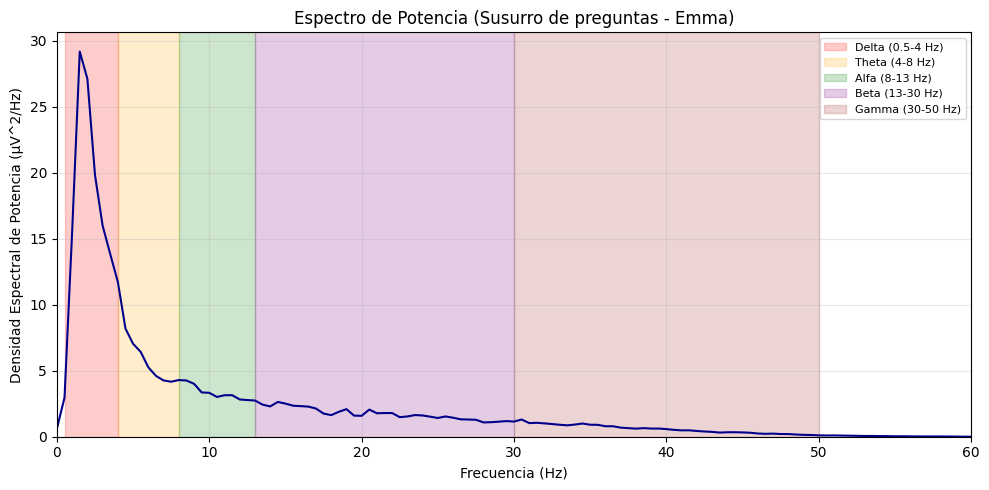

-------------------------------------------------------------------------------------------
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_vivi_filtrada.png
  -> Banda de frecuencia dominante para Susurro de preguntas - Vivi: Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_vivi_espectro.png


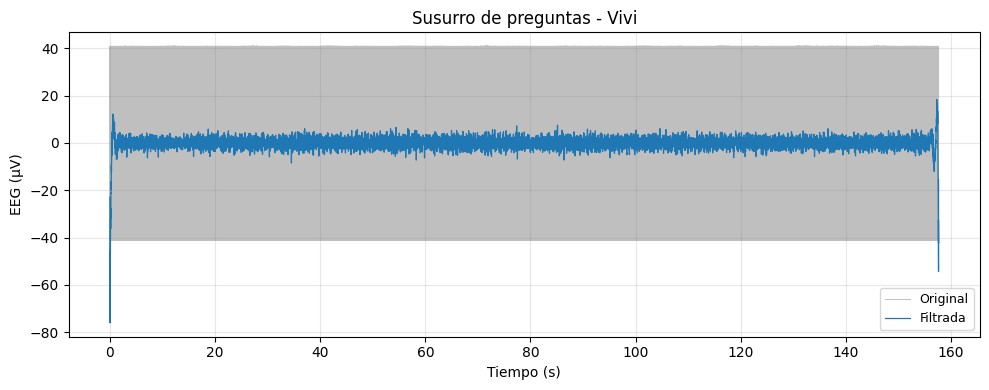

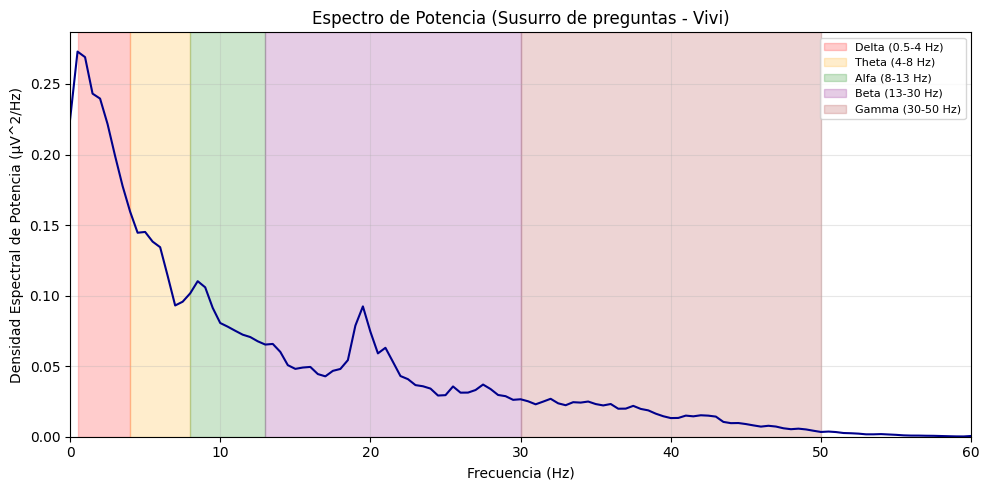

-------------------------------------------------------------------------------------------
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_emma_filtrada.png
  -> Banda de frecuencia dominante para Música tranquila - Emma: Beta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_emma_espectro.png


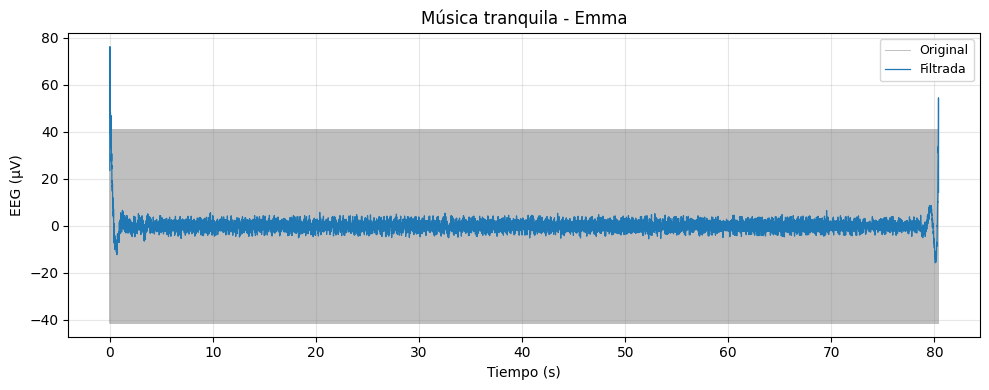

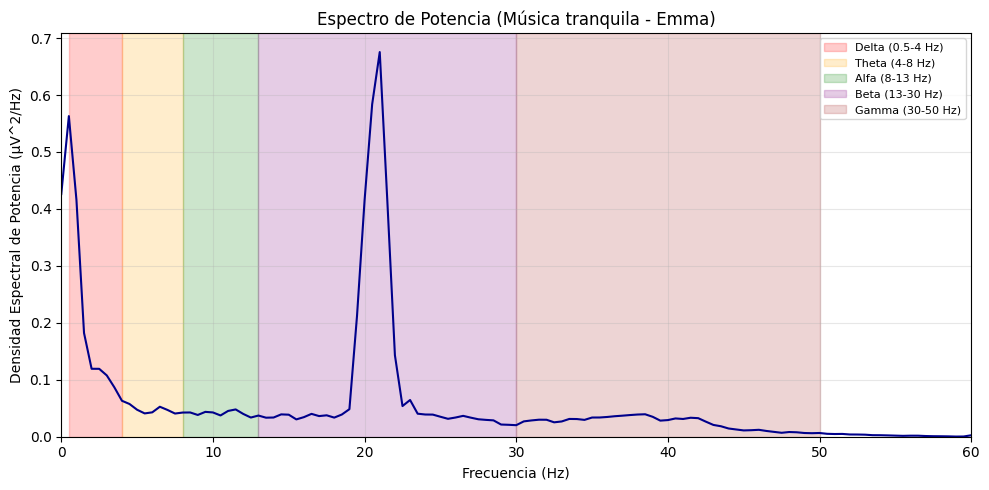

-------------------------------------------------------------------------------------------
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_vivi_filtrada.png
  -> Banda de frecuencia dominante para Música tranquila - Vivi: Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_vivi_espectro.png


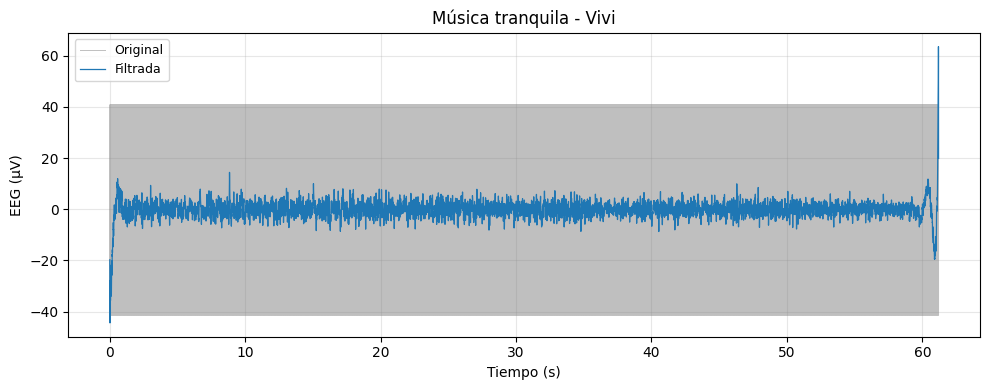

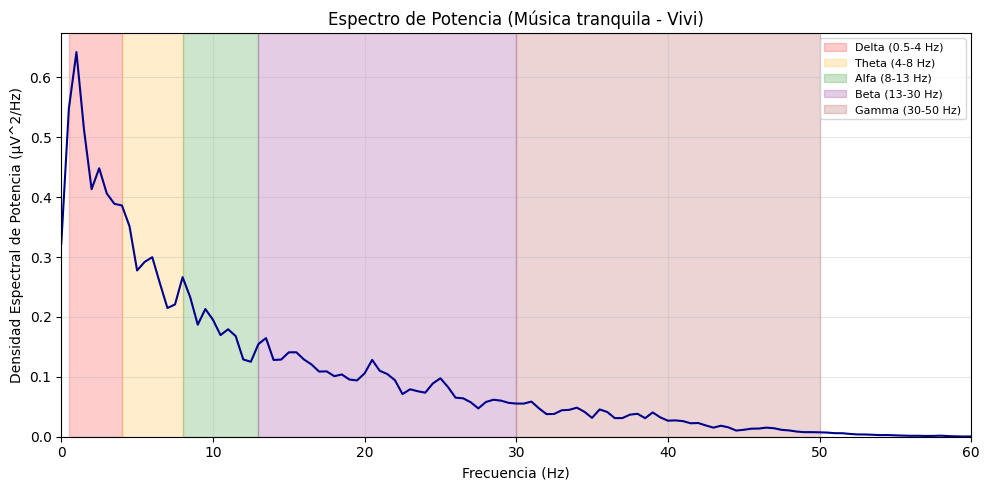

-------------------------------------------------------------------------------------------
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_emma_filtrada.png
  -> Banda de frecuencia dominante para Música hardcore - Emma: Beta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_emma_espectro.png


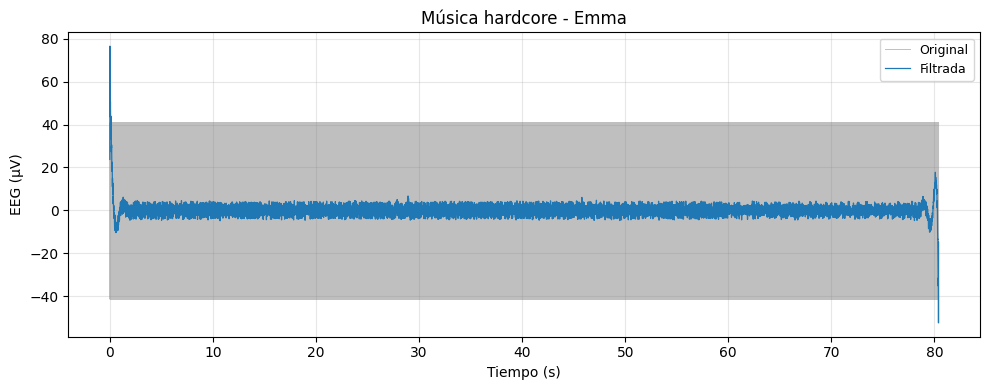

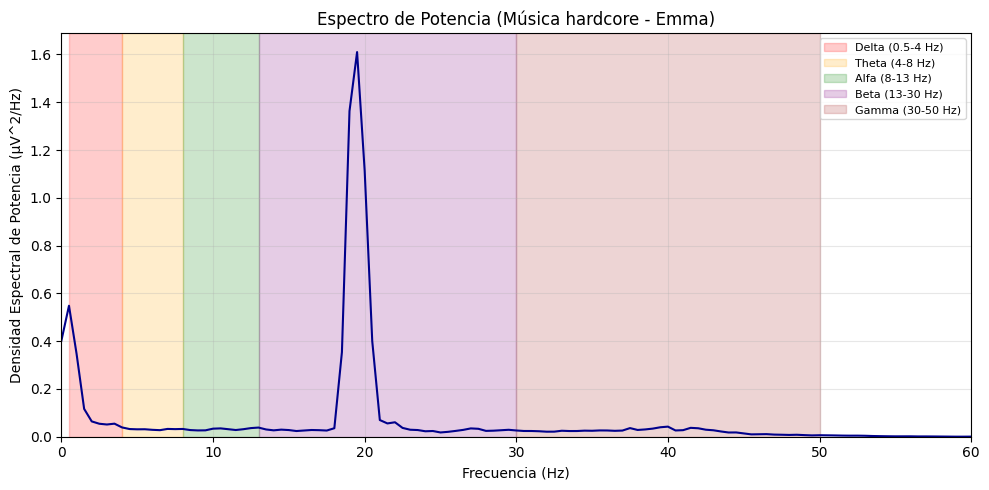

-------------------------------------------------------------------------------------------
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_vivi_filtrada.png
  -> Banda de frecuencia dominante para Música hardcore - Vivi: Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_vivi_espectro.png


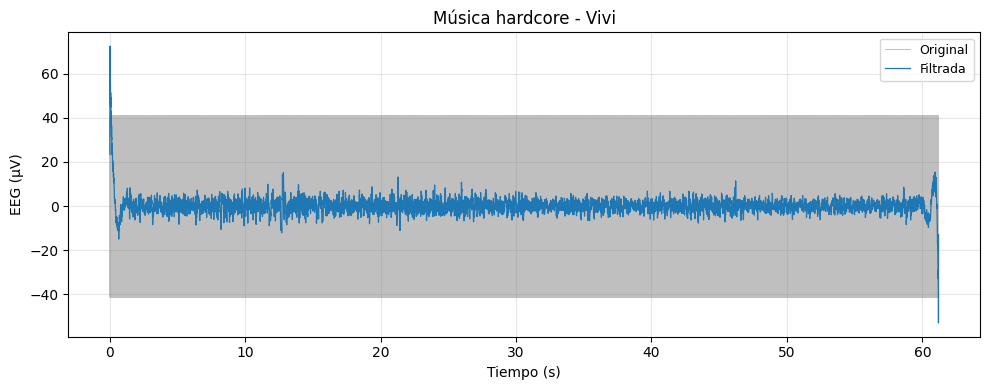

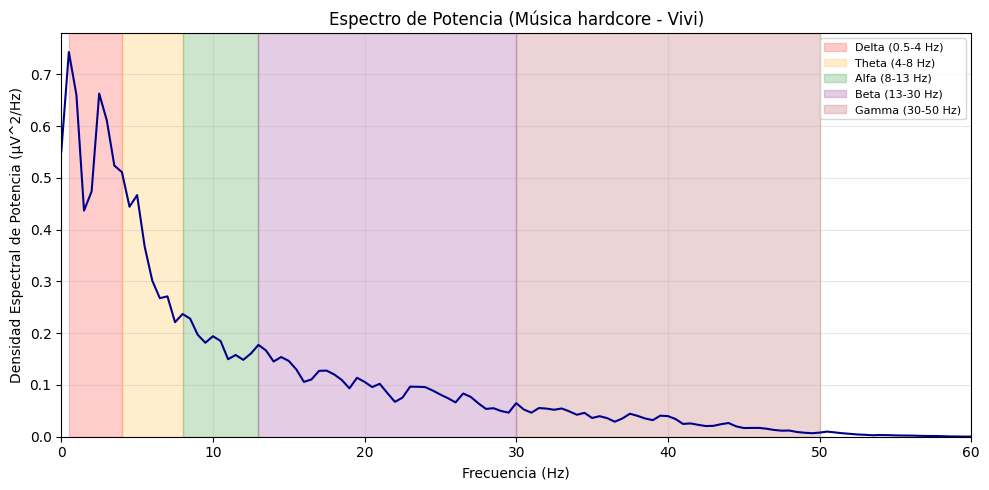

-------------------------------------------------------------------------------------------


In [ ]:
for nombre_grupo, dict_sujetos in ARCHIVOS.items():
    for sujeto, nombre_archivo in dict_sujetos.items():

        ruta = os.path.join(CARPETA_DATOS, nombre_archivo)
        resultado = cargar_senal(ruta, CANAL)

        if resultado is None:
            continue

        t, senal, senal_cr, fs = resultado
        senal_filtrada = filtrar_eeg(senal, fs)

        titulo = f"{nombre_grupo} - {sujeto}"
        nombre_fig_filtrada = f"{nombre_grupo}_{sujeto}_filtrada.png".lower().replace(" ", "_")

        # Graficar señal filtrada
        graficar_senal_filtrada(t, senal, senal_filtrada, titulo, unidad=UNIDAD,
                                 carpeta_salida=CARPETA_SALIDA, nombre_fig=nombre_fig_filtrada)

        # Calcular espectro de potencia
        frecuencias, psd, potencia_por_banda = calcular_espectro_eeg(senal_filtrada, fs)

        # Identificar la banda dominante
        if potencia_por_banda:
            banda_dominante = max(potencia_por_banda, key=potencia_por_banda.get)
            print(f"  -> Banda de frecuencia dominante para {titulo}: {banda_dominante}")
        else:
            print(f"  [!] No se pudo calcular la potencia por banda para {titulo}.")

        # Graficar espectro de potencia
        nombre_fig_espectro = f"{nombre_grupo}_{sujeto}_espectro.png".lower().replace(" ", "_")
        graficar_espectro_eeg(frecuencias, psd, potencia_por_banda, titulo, fs,
                               carpeta_salida=CARPETA_SALIDA, nombre_fig=nombre_fig_espectro)

        plt.show()

        print("-------------------------------------------------------------------------------------------")

## 7. Segundo canal EEG (A2) recuperado mediante la fórmula de transferencia manual

Como se identificó al revisar el header de los archivos, el canal A2 fue registrado con el electrodo colocado también en la frente (FP1 o FP2, según la Figura 9), pero quedó mal etiquetado como sensor **"EGG"** (electrogastrografía) en la configuración de OpenSignals, en vez de **"EEG"**. Esto es relevante porque `opensignalsreader` convierte automáticamente cada canal según la fórmula de transferencia de su sensor declarado en el header: si se usa `acq.signal("EGG")`, la librería aplicaría la ganancia del sensor EGG (G = 6110), que es incorrecta para una señal que físicamente es EEG (G = 40000).

Para recuperar este canal correctamente, se aplica manualmente la fórmula oficial de transferencia del sensor EEG de BITalino sobre el valor crudo (ADC) del canal A2:

$$EEG(\mu V) = \left(\frac{\left(\dfrac{ADC}{2^{n}} - 0.5\right) \times V_{CC}}{G_{EEG}}\right) \times 10^{6}$$

con $n = 10$ bits, $V_{CC} = 3.3\,V$ y $G_{EEG} = 40000$. Esto permite incluir en el análisis una segunda señal EEG (A2), procesada con el mismo pipeline de atenuación de artefactos y filtrado que el canal A6, para poder comparar ambos electrodos frontales (FP1 vs FP2) en cada condición.

In [ ]:
def convertir_eeg_manual(adc_crudo, n=10, vcc=3.3, ganancia=40000):
    """
    Aplica la fórmula de transferencia oficial del sensor EEG de BITalino
    sobre un valor crudo (ADC), usando la ganancia correcta de EEG en vez
    de la ganancia del sensor con el que el canal quedó mal etiquetado.
    """
    return ((((adc_crudo / (2 ** n)) - 0.5) * vcc) / ganancia) * 1e6


def cargar_segundo_canal_eeg(ruta_archivo, sensor_label="EGG", n=10, vcc=3.3, ganancia=40000):
    """
    Carga el canal A2 (etiquetado como 'EGG' en el header, pero
    correspondiente físicamente a un segundo electrodo EEG frontal) y lo
    convierte a µV aplicando manualmente la fórmula de transferencia del
    sensor EEG.

    Devuelve (t, senal_uv, adc_crudo, fs), o None si el archivo no existe
    o no contiene el canal esperado.
    """
    if not os.path.isfile(ruta_archivo):
        print(f"  [!] No se encontró el archivo: {ruta_archivo} (aún no agregado)")
        return None

    try:
        acq = OpenSignalsReader(ruta_archivo)
    except Exception as e:
        print(f"  [!] Error al procesar {ruta_archivo} para el segundo canal: {e}. Se omite.")
        return None

    try:
        adc_crudo = acq.raw(sensor_label)
        fs = acq.sampling_rate
    except (ValueError, AttributeError) as e:
        print(f"  [!] El archivo {ruta_archivo} no tiene el canal '{sensor_label}': {e}. Se omite.")
        return None

    senal_uv = convertir_eeg_manual(adc_crudo, n=n, vcc=vcc, ganancia=ganancia)
    t = np.arange(len(senal_uv)) / fs

    return t, senal_uv, adc_crudo, fs

## 9. Ejecutar: señal y espectro de ambos canales EEG (A6 y A2), con atenuación de artefactos

Se recorren los 10 registros y, para cada uno, se procesan **ambos canales EEG disponibles** (A6, el ya identificado como "EEG" en el header, y A2, recuperado manualmente en la sección anterior). A cada canal se le aplica primero la eliminación de artefactos de amplitud y luego el filtrado (pasa-banda + notch de línea eléctrica + notch adicional en 20 Hz), antes de graficar la señal en el tiempo y su espectro de potencia.

/tmp/ipykernel_1441/920855904.py:15: UserWarning: Valor mínimo de la señal EGG (-0.27mV) está por debajo del rango esperado del sensor (-0.27mV).
  warnings.warn(
/tmp/ipykernel_1441/920855904.py:15: UserWarning: Valor mínimo de la señal EEG (-41.25µV) está por debajo del rango esperado del sensor (-41.24µV).
  warnings.warn(


  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_emma_a6_eeg_filtrada.png


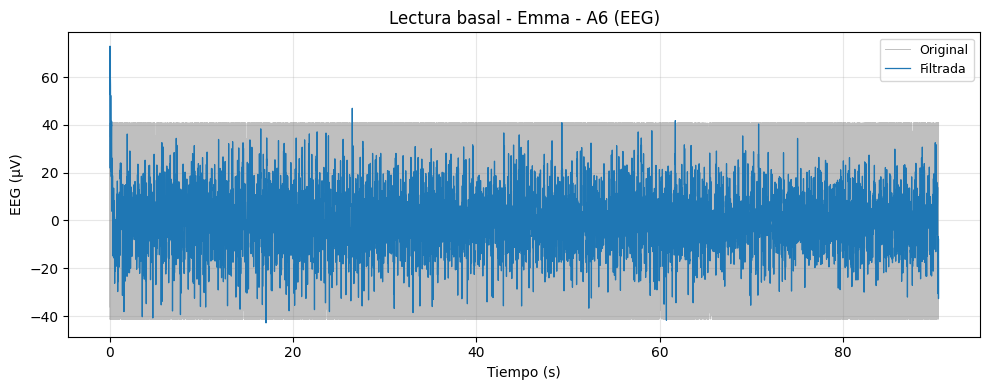

/tmp/ipykernel_1441/3637997105.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  potencia = np.trapz(psd[idx_banda], frecuencias[idx_banda])


  -> Banda de frecuencia dominante para Lectura basal - Emma - A6 (EEG): Beta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_emma_a6_eeg_espectro.png


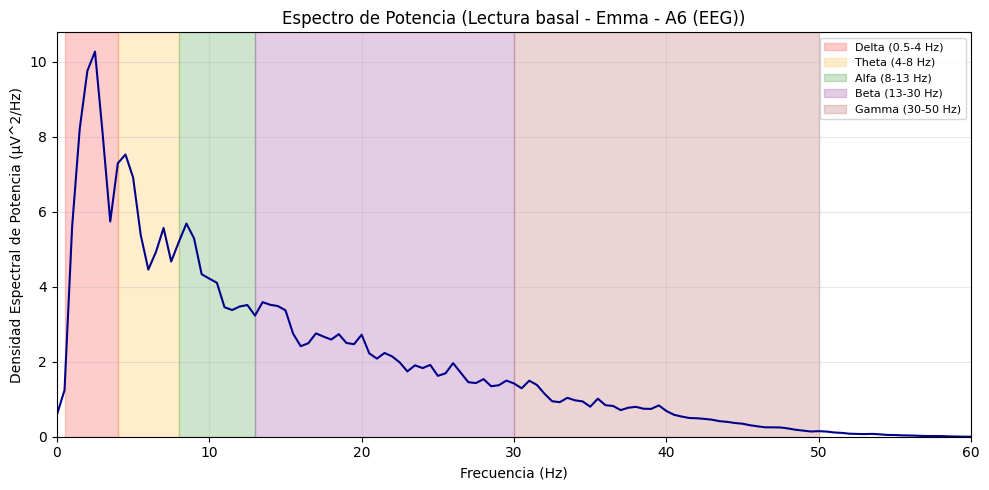

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_emma_a2_eeg_recuperado_filtrada.png


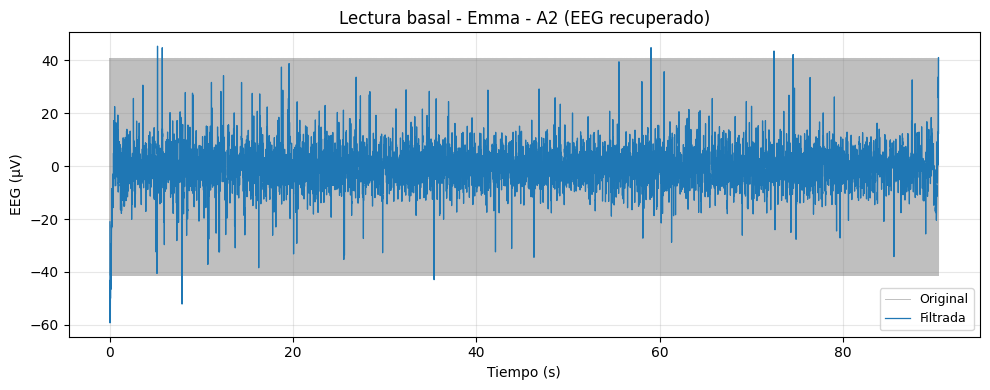

  -> Banda de frecuencia dominante para Lectura basal - Emma - A2 (EEG recuperado): Beta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_emma_a2_eeg_recuperado_espectro.png


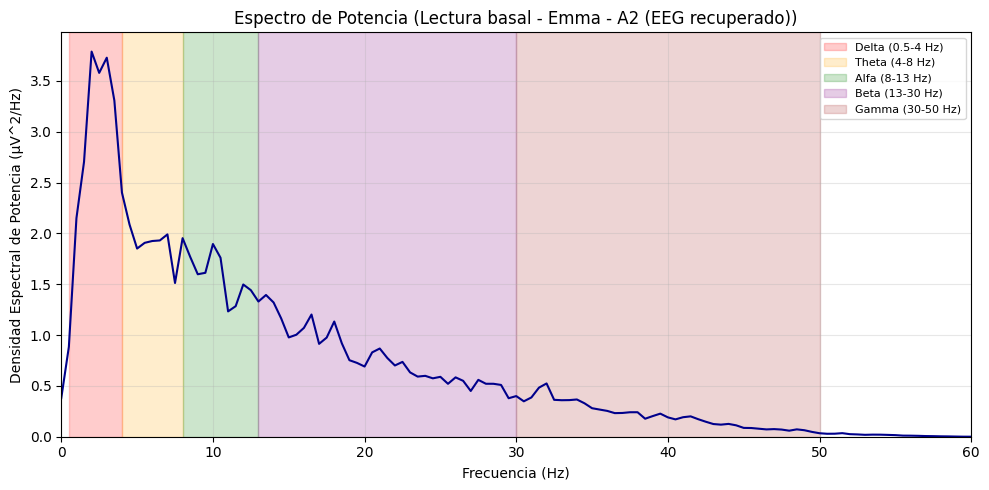

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_vivi_a6_eeg_filtrada.png


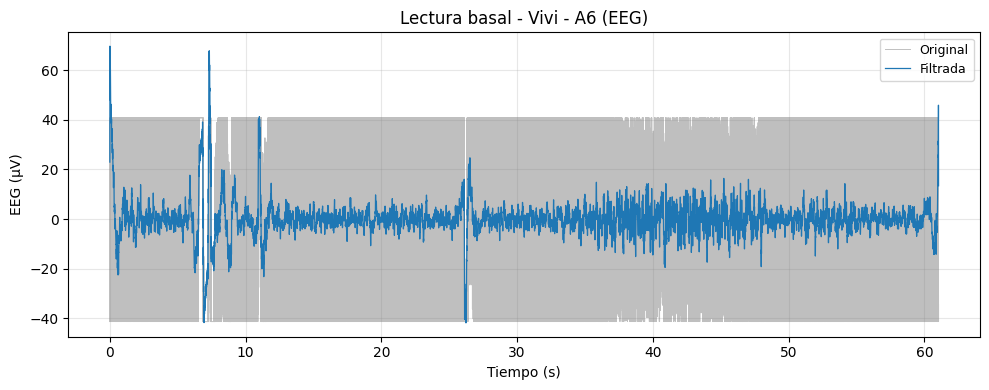

  -> Banda de frecuencia dominante para Lectura basal - Vivi - A6 (EEG): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_vivi_a6_eeg_espectro.png


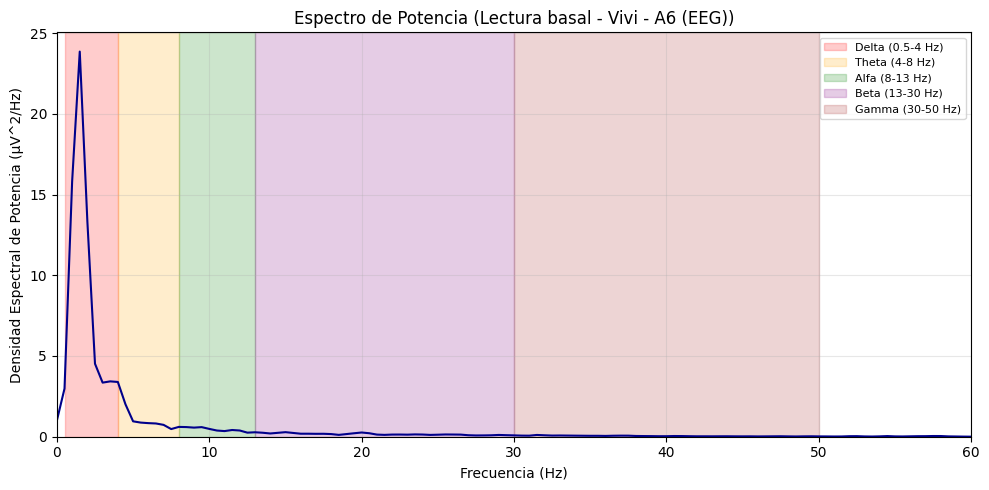

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_vivi_a2_eeg_recuperado_filtrada.png


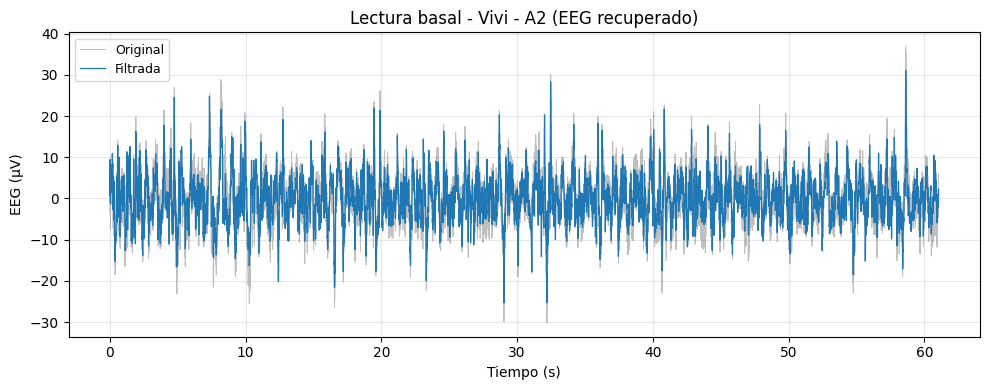

  -> Banda de frecuencia dominante para Lectura basal - Vivi - A2 (EEG recuperado): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/lectura_basal_vivi_a2_eeg_recuperado_espectro.png


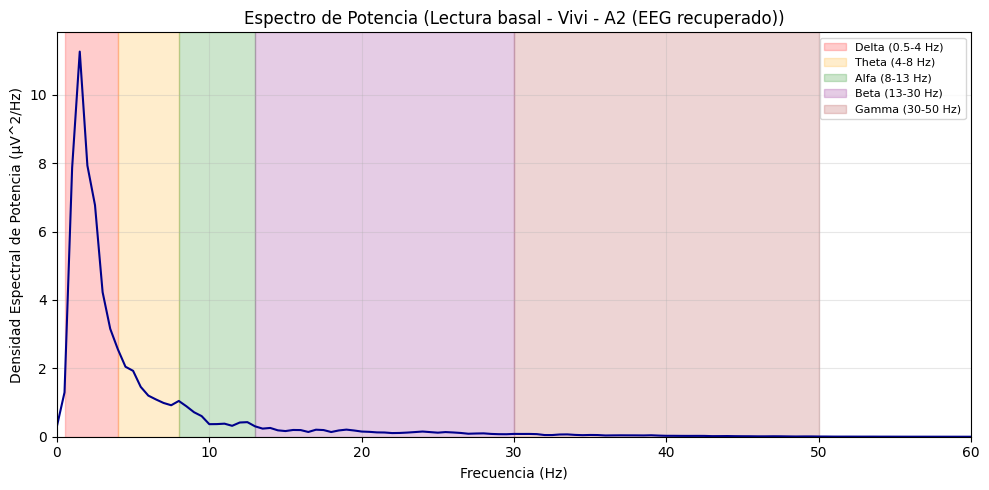

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_emma_a6_eeg_filtrada.png


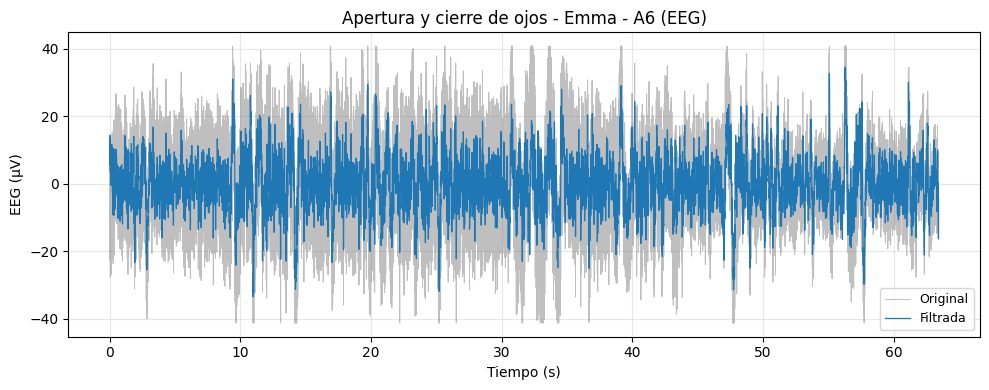

  -> Banda de frecuencia dominante para Apertura y cierre de ojos - Emma - A6 (EEG): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_emma_a6_eeg_espectro.png


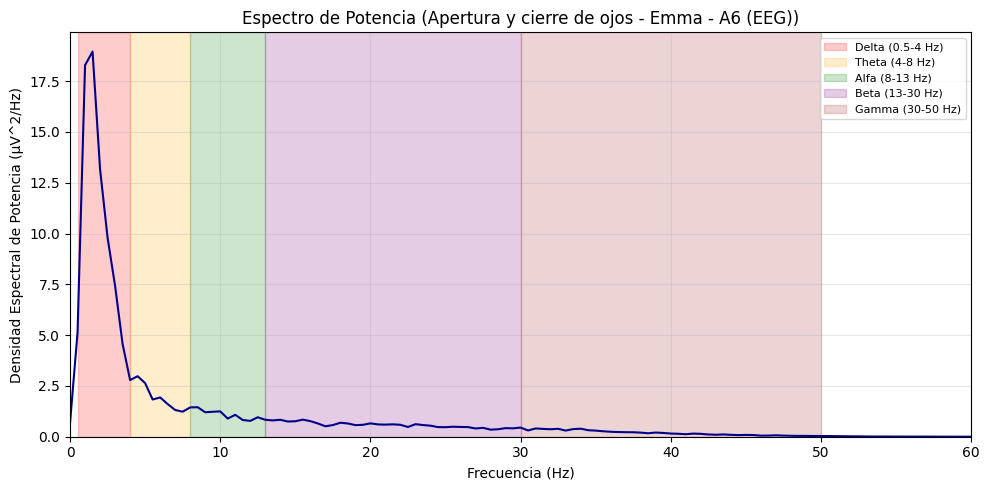

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_emma_a2_eeg_recuperado_filtrada.png


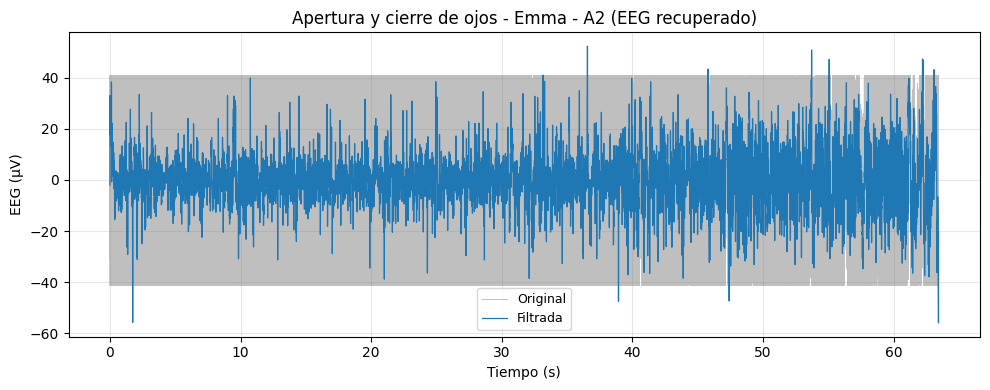

  -> Banda de frecuencia dominante para Apertura y cierre de ojos - Emma - A2 (EEG recuperado): Beta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_emma_a2_eeg_recuperado_espectro.png


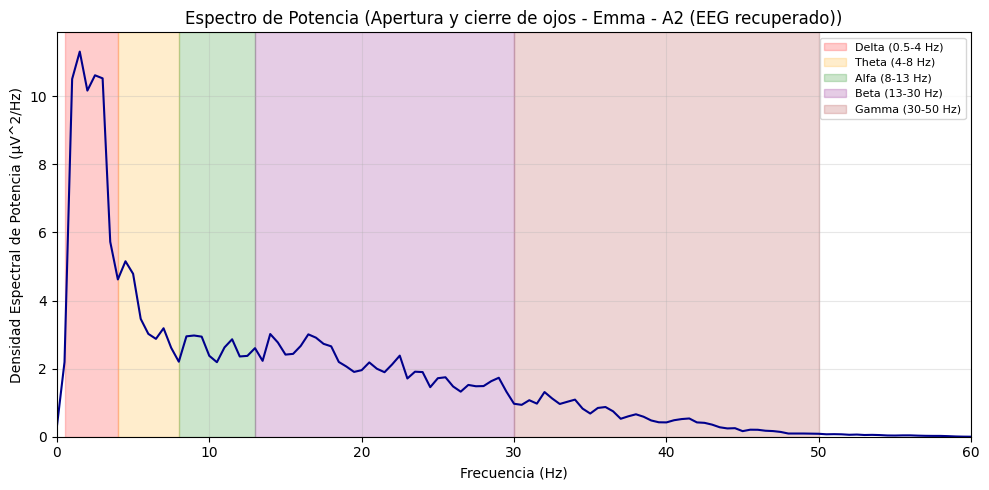

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_vivi_a6_eeg_filtrada.png


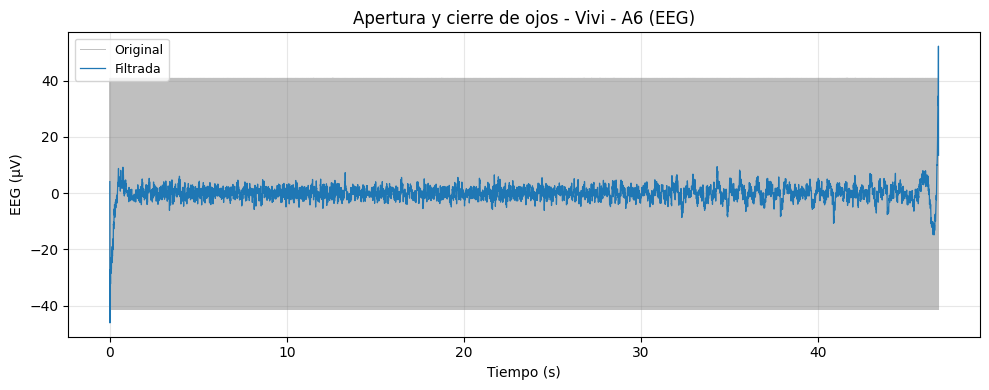

  -> Banda de frecuencia dominante para Apertura y cierre de ojos - Vivi - A6 (EEG): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_vivi_a6_eeg_espectro.png


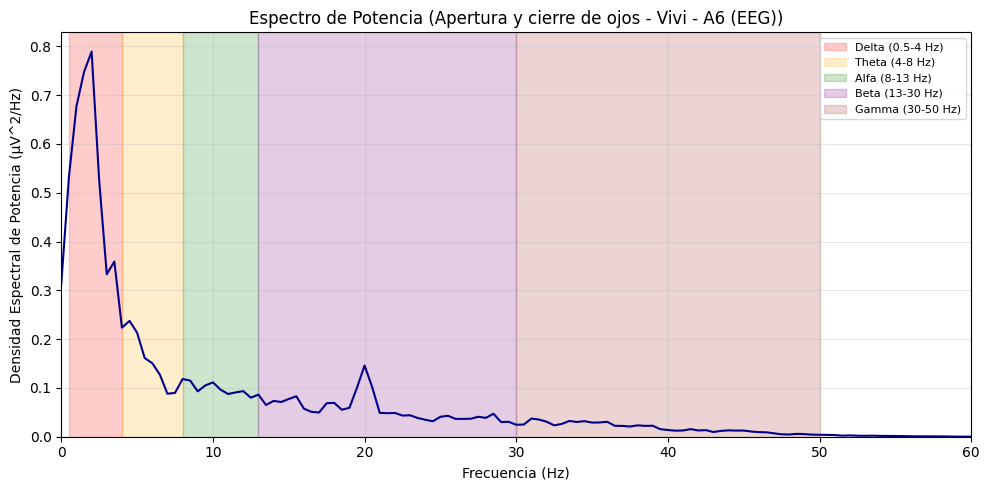

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_vivi_a2_eeg_recuperado_filtrada.png


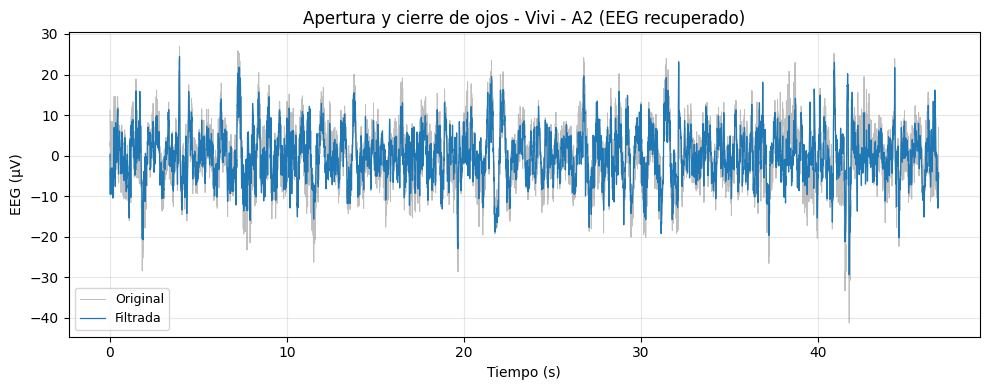

  -> Banda de frecuencia dominante para Apertura y cierre de ojos - Vivi - A2 (EEG recuperado): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/apertura_y_cierre_de_ojos_vivi_a2_eeg_recuperado_espectro.png


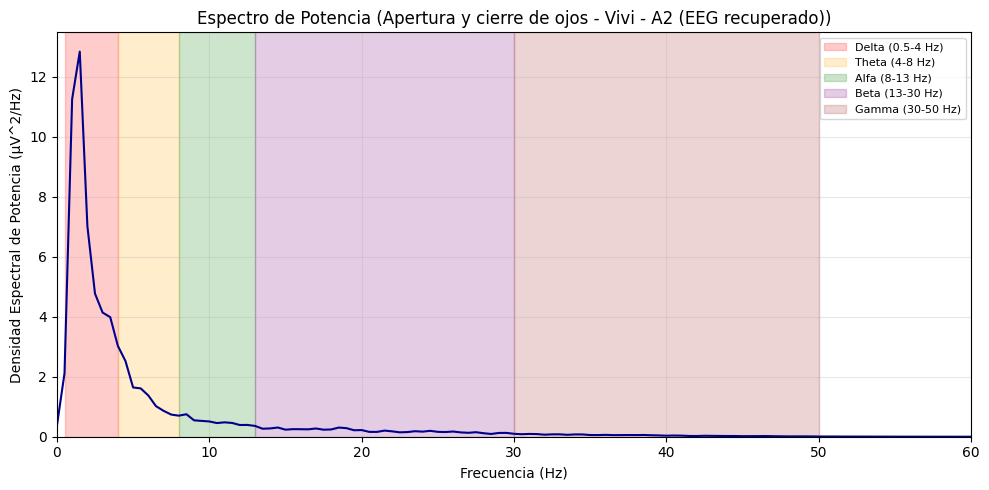

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_emma_a6_eeg_filtrada.png


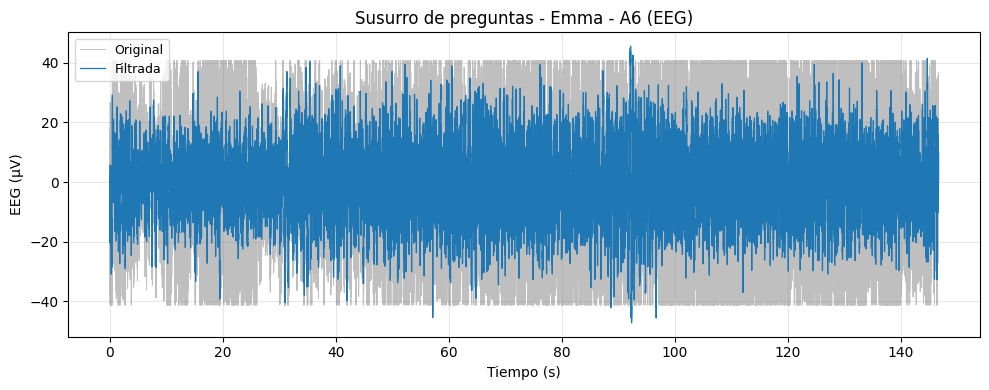

  -> Banda de frecuencia dominante para Susurro de preguntas - Emma - A6 (EEG): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_emma_a6_eeg_espectro.png


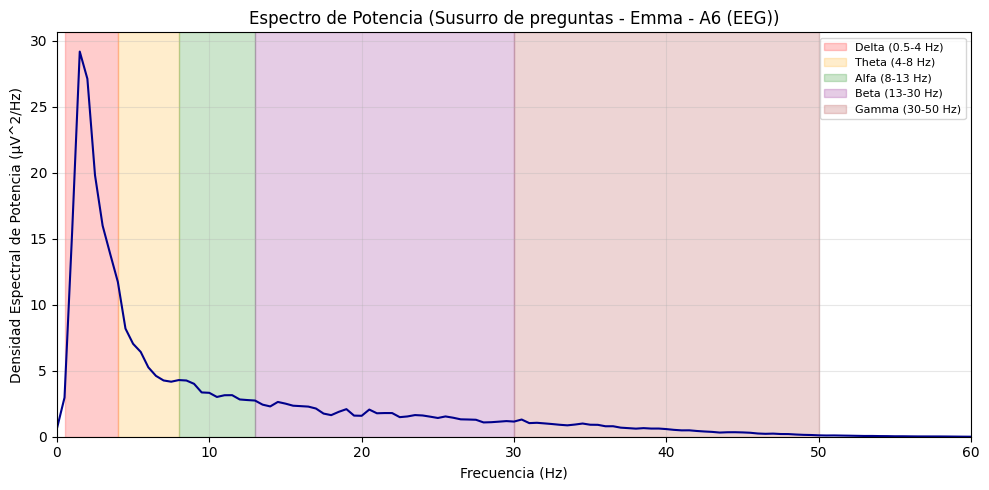

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_emma_a2_eeg_recuperado_filtrada.png


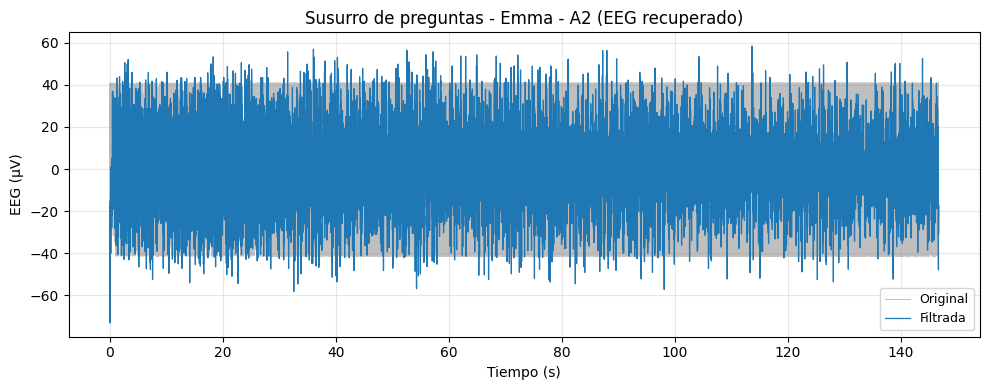

  -> Banda de frecuencia dominante para Susurro de preguntas - Emma - A2 (EEG recuperado): Beta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_emma_a2_eeg_recuperado_espectro.png


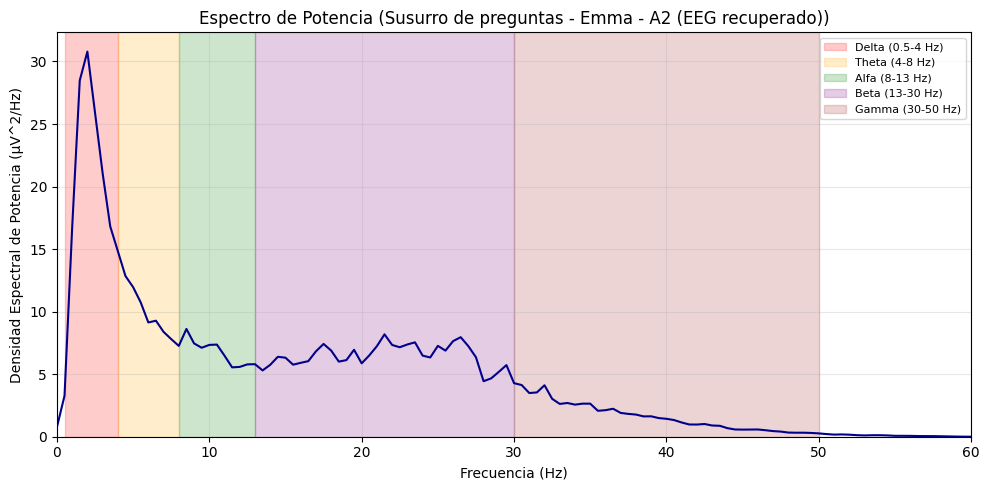

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_vivi_a6_eeg_filtrada.png


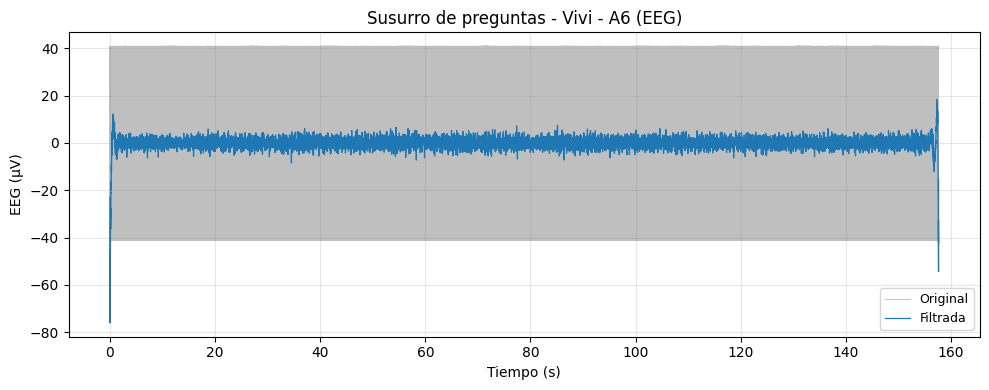

  -> Banda de frecuencia dominante para Susurro de preguntas - Vivi - A6 (EEG): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_vivi_a6_eeg_espectro.png


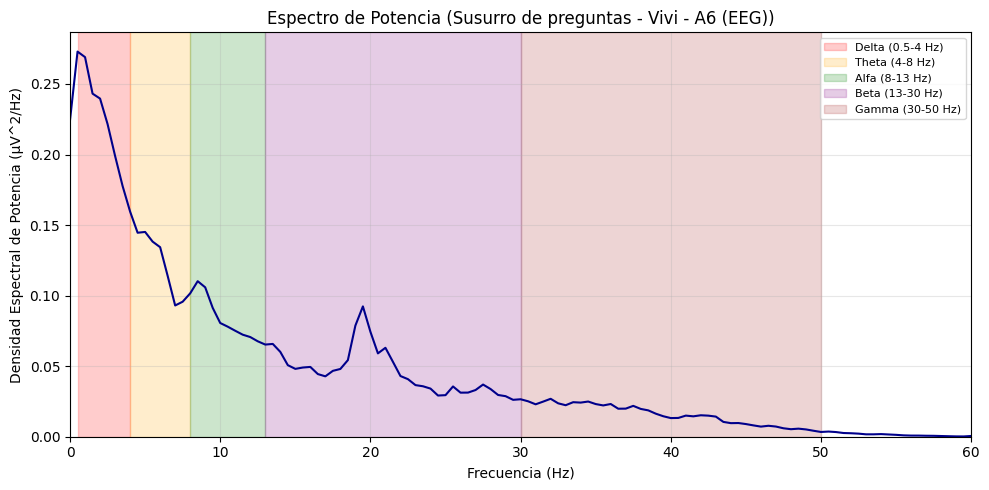

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_vivi_a2_eeg_recuperado_filtrada.png


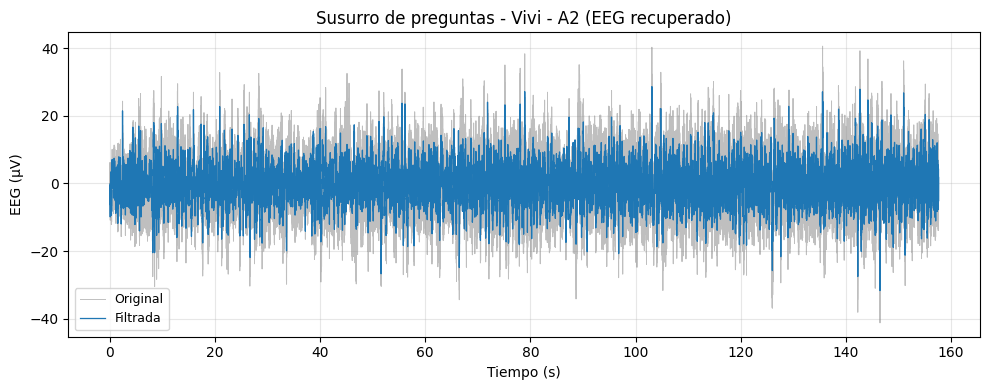

  -> Banda de frecuencia dominante para Susurro de preguntas - Vivi - A2 (EEG recuperado): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/susurro_de_preguntas_vivi_a2_eeg_recuperado_espectro.png


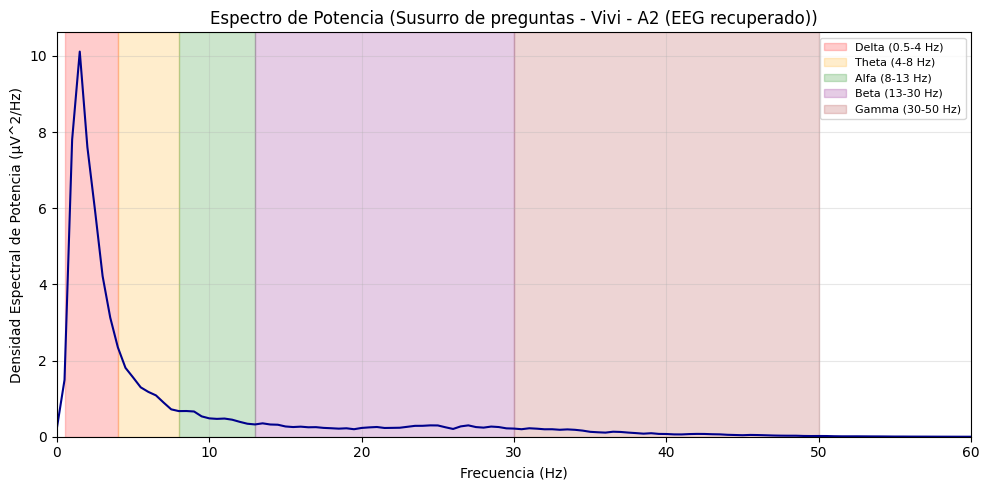

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_emma_a6_eeg_filtrada.png


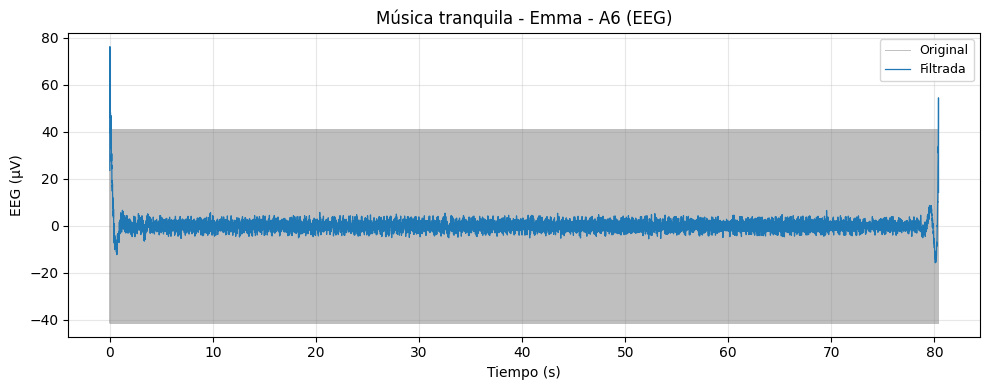

  -> Banda de frecuencia dominante para Música tranquila - Emma - A6 (EEG): Beta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_emma_a6_eeg_espectro.png


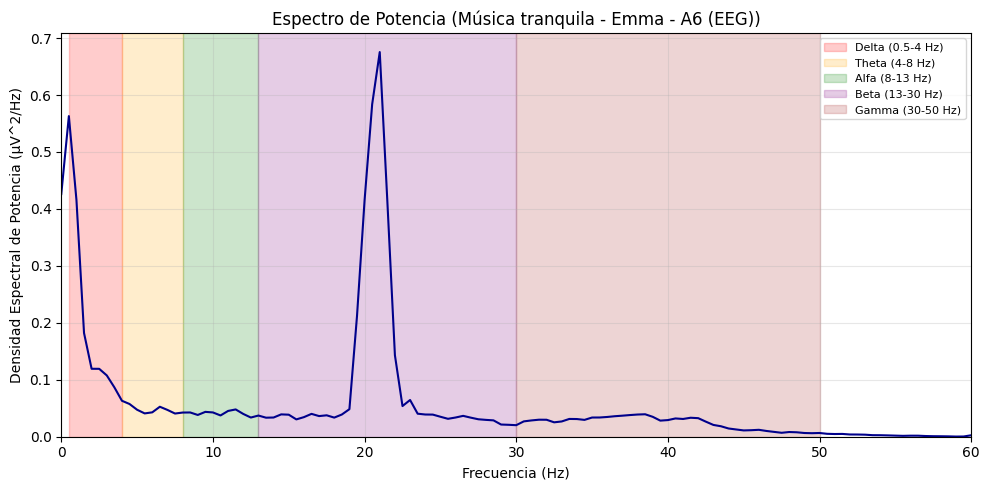

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_emma_a2_eeg_recuperado_filtrada.png


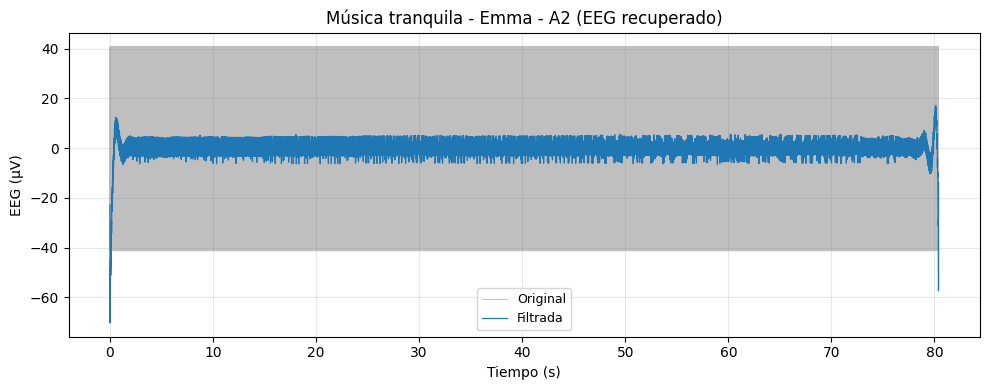

  -> Banda de frecuencia dominante para Música tranquila - Emma - A2 (EEG recuperado): Gamma
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_emma_a2_eeg_recuperado_espectro.png


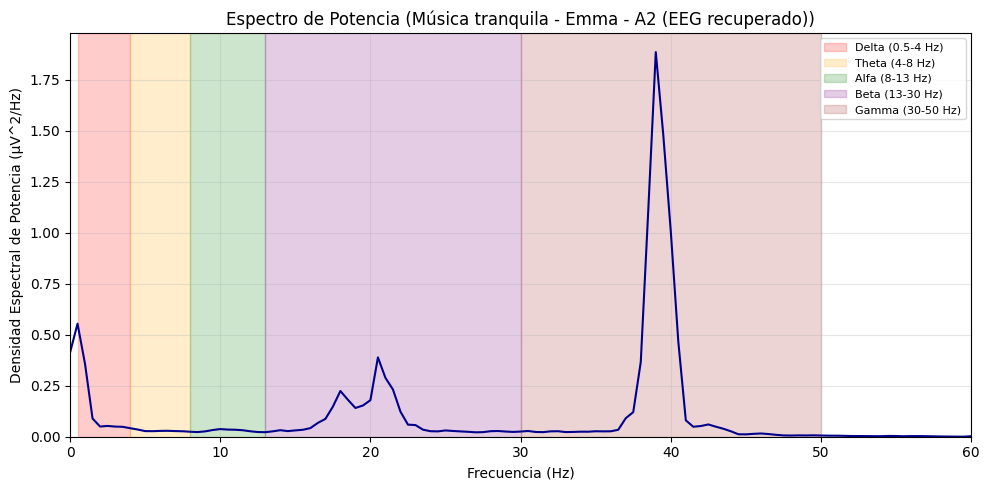

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_vivi_a6_eeg_filtrada.png


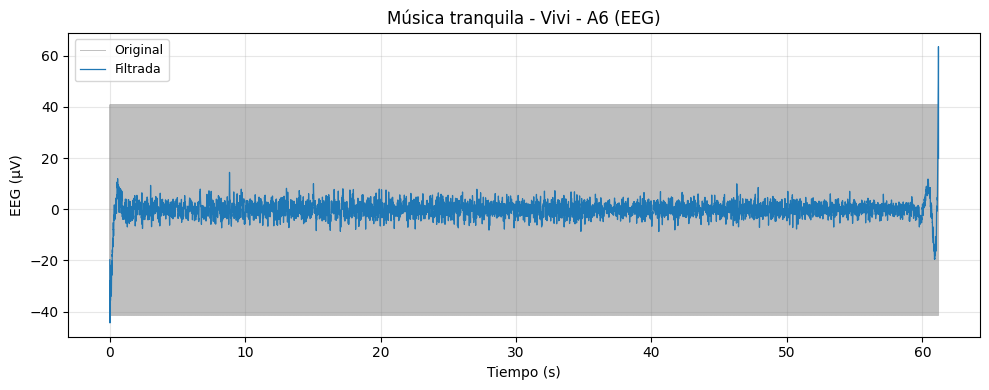

  -> Banda de frecuencia dominante para Música tranquila - Vivi - A6 (EEG): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_vivi_a6_eeg_espectro.png


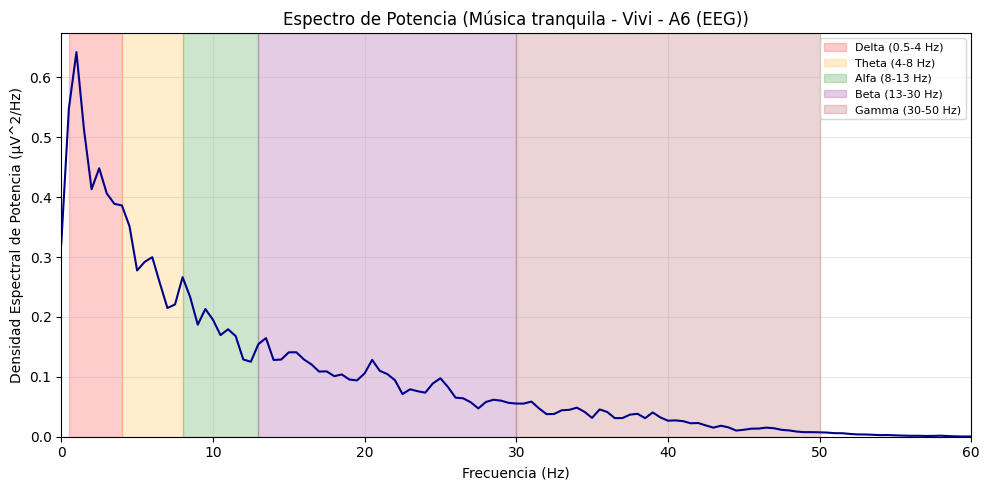

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_vivi_a2_eeg_recuperado_filtrada.png


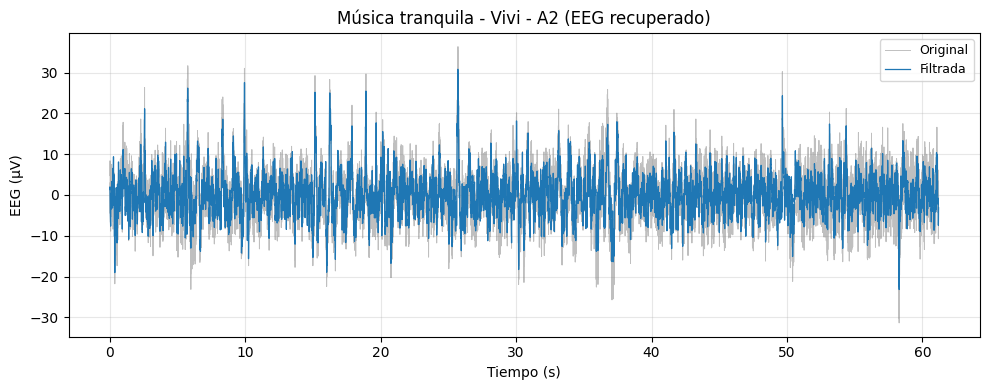

  -> Banda de frecuencia dominante para Música tranquila - Vivi - A2 (EEG recuperado): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_tranquila_vivi_a2_eeg_recuperado_espectro.png


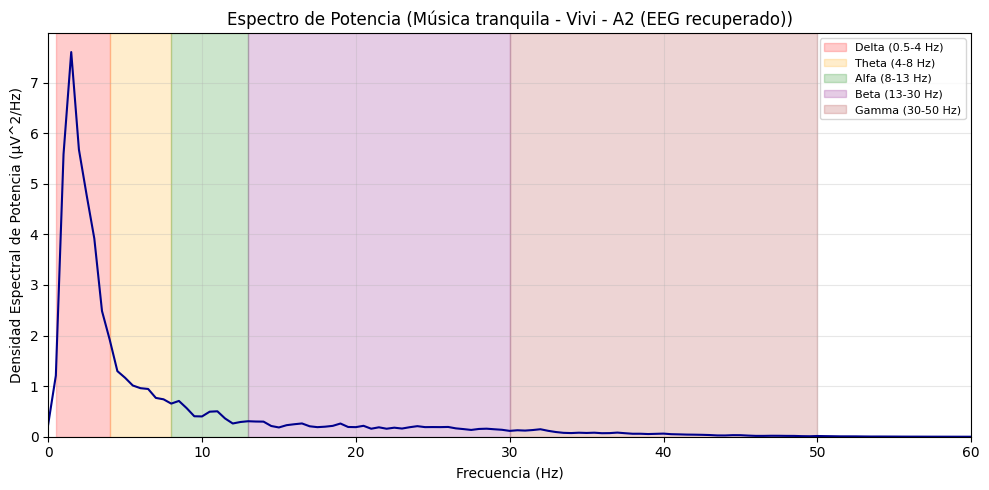

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_emma_a6_eeg_filtrada.png


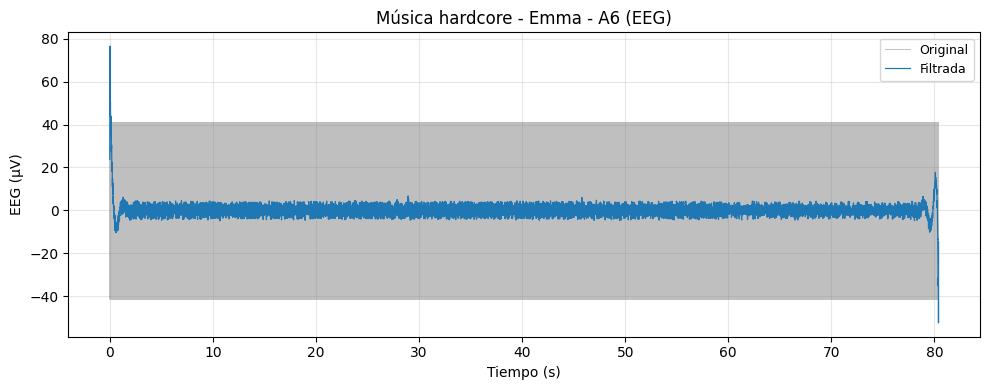

  -> Banda de frecuencia dominante para Música hardcore - Emma - A6 (EEG): Beta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_emma_a6_eeg_espectro.png


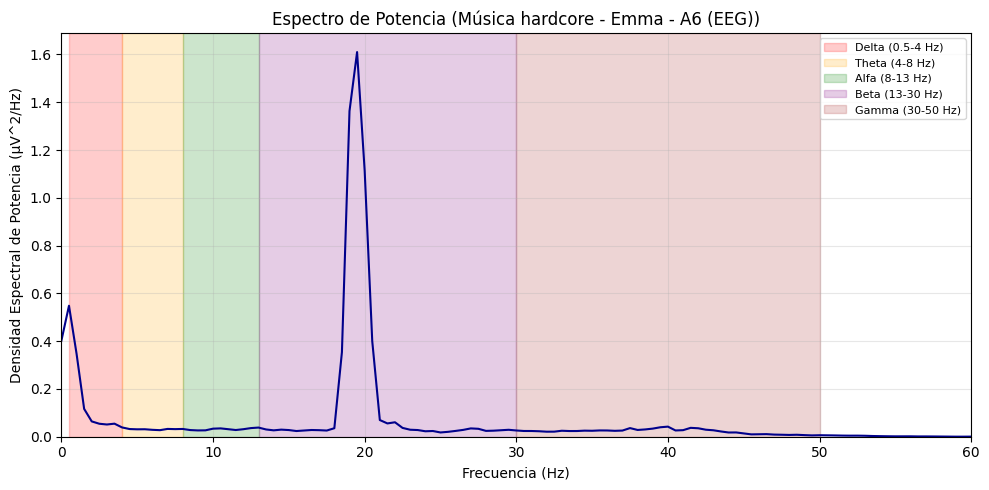

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_emma_a2_eeg_recuperado_filtrada.png


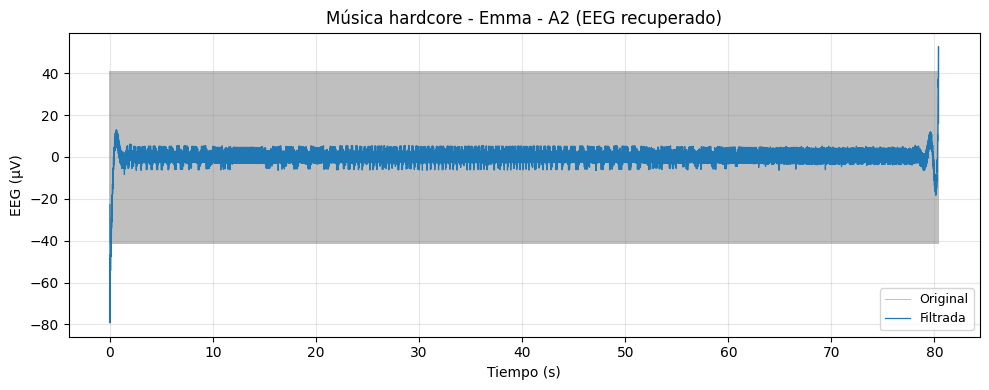

  -> Banda de frecuencia dominante para Música hardcore - Emma - A2 (EEG recuperado): Gamma
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_emma_a2_eeg_recuperado_espectro.png


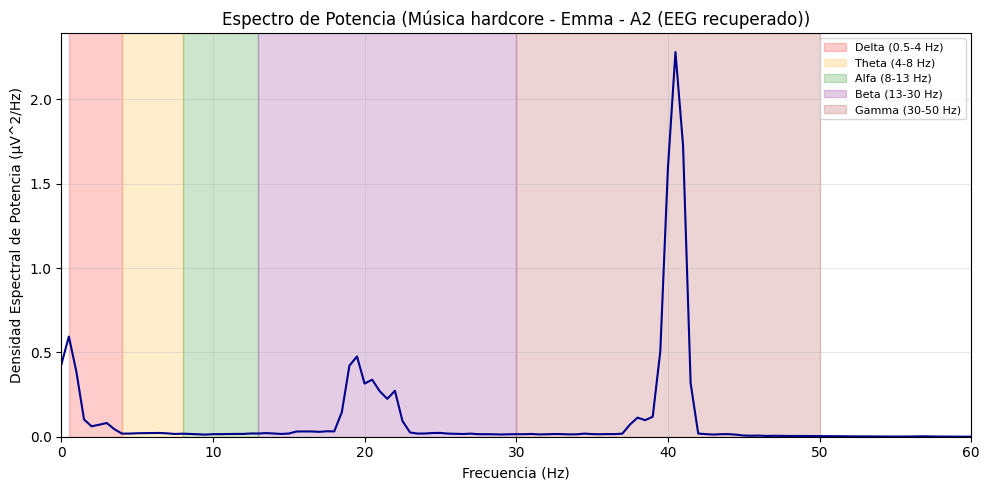

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_vivi_a6_eeg_filtrada.png


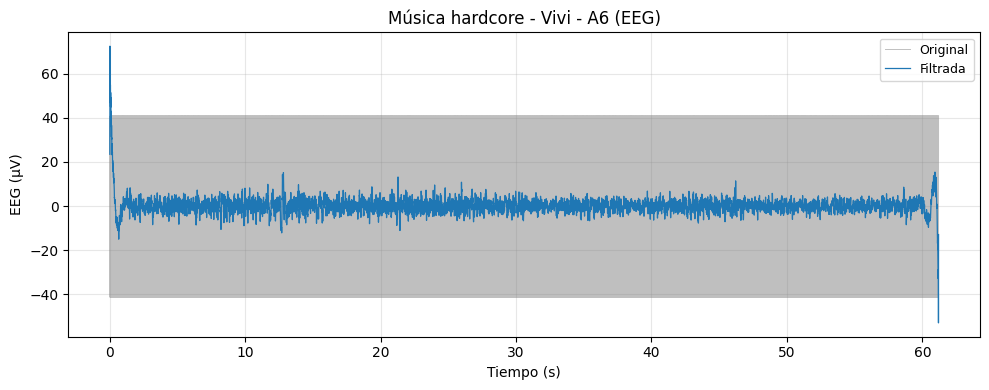

  -> Banda de frecuencia dominante para Música hardcore - Vivi - A6 (EEG): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_vivi_a6_eeg_espectro.png


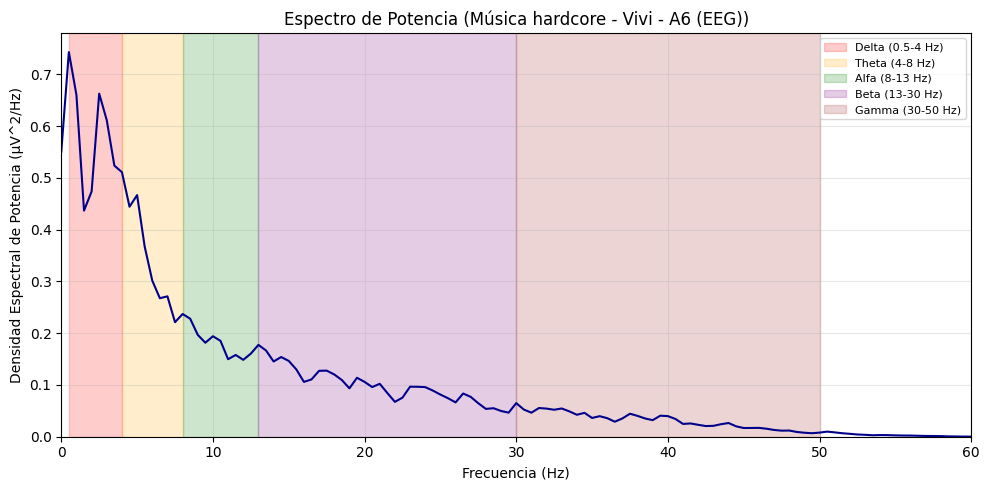

  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_vivi_a2_eeg_recuperado_filtrada.png


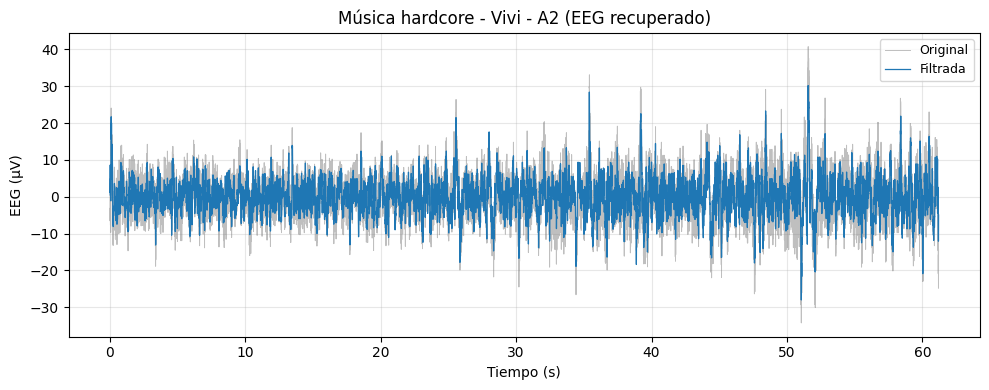

  -> Banda de frecuencia dominante para Música hardcore - Vivi - A2 (EEG recuperado): Delta
  -> Figura de espectro guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_bitalino/música_hardcore_vivi_a2_eeg_recuperado_espectro.png


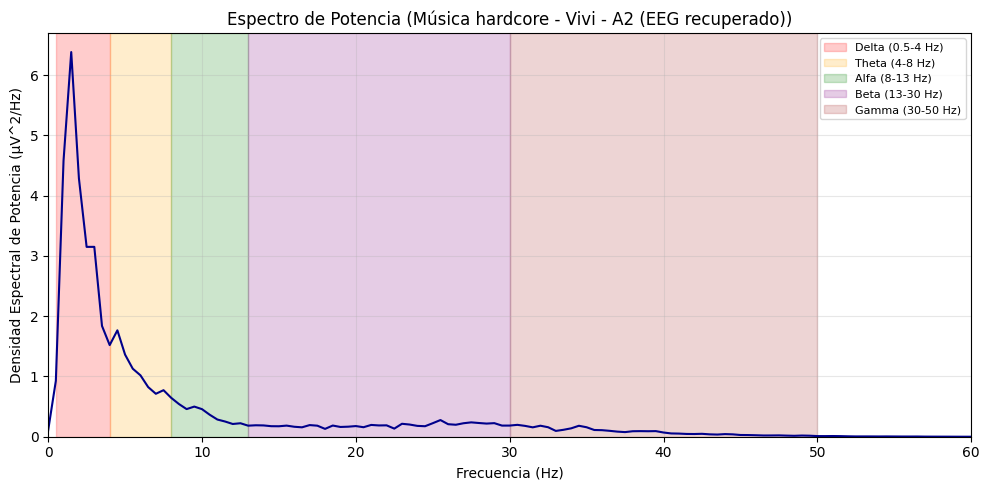

In [ ]:
for nombre_grupo, dict_sujetos in ARCHIVOS.items():
    for sujeto, nombre_archivo in dict_sujetos.items():

        ruta = os.path.join(CARPETA_DATOS, nombre_archivo)

        # --- Canal A6 (EEG, ya identificado en el header) ---
        resultado_a6 = cargar_senal(ruta, CANAL)

        # --- Canal A2 (EEG recuperado, mal etiquetado como EGG) ---
        resultado_a2 = cargar_segundo_canal_eeg(ruta)

        canales = [
            ("A6 (EEG)", resultado_a6),
            ("A2 (EEG recuperado)", resultado_a2),
        ]

        for etiqueta_canal, resultado in canales:
            if resultado is None:
                continue

            t, senal, _, fs = resultado
            senal_filtrada = filtrar_eeg(senal, fs)

            titulo = f"{nombre_grupo} - {sujeto} - {etiqueta_canal}"
            nombre_base = f"{nombre_grupo}_{sujeto}_{etiqueta_canal}".lower().replace(" ", "_").replace("(", "").replace(")", "")

            # Graficar señal original vs filtrada
            nombre_fig_filtrada = f"{nombre_base}_filtrada.png"
            graficar_senal_filtrada(t, senal, senal_filtrada, titulo, unidad=UNIDAD,
                                     carpeta_salida=CARPETA_SALIDA, nombre_fig=nombre_fig_filtrada)
            plt.show()

            # Calcular y graficar espectro de potencia
            frecuencias, psd, potencia_por_banda = calcular_espectro_eeg(senal_filtrada, fs)

            if potencia_por_banda:
                banda_dominante = max(potencia_por_banda, key=potencia_por_banda.get)
                print(f"  -> Banda de frecuencia dominante para {titulo}: {banda_dominante}")

            nombre_fig_espectro = f"{nombre_base}_espectro.png"
            graficar_espectro_eeg(frecuencias, psd, potencia_por_banda, titulo, fs,
                                   carpeta_salida=CARPETA_SALIDA, nombre_fig=nombre_fig_espectro)
            plt.show()